In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, roc_auc_score, average_precision_score, brier_score_loss
import tqdm
import pymc as pm
import arviz as az

In [4]:
base = "/Users/kyledorman/data/results/estuary/train/20260305-095554/seasonal_drivers"

SKIP_REGIONS = [12103]

daily = pd.read_parquet(f"{base}/daily_driver_table.parquet")
daily = daily[~daily.region.isin(SKIP_REGIONS)]
monthly = pd.read_parquet(f"{base}/monthly_driver_table.parquet")
monthly = monthly[~monthly.region.isin(SKIP_REGIONS)]
seasonal = pd.read_parquet(f"{base}/seasonal_driver_table.parquet")
seasonal = seasonal[~seasonal.region.isin(SKIP_REGIONS)]
wy_seasonal = pd.read_parquet(f"{base}/wy_seasonal_driver_table.parquet")
wy_seasonal = wy_seasonal[~wy_seasonal.region.isin(SKIP_REGIONS)]
annual = pd.read_parquet(f"{base}/annual_driver_table.parquet")
annual = annual[~annual.region.isin(SKIP_REGIONS)]

print("daily:", daily.shape)

print("monthly:", monthly.shape)

print("seasonal:", seasonal.shape)

print("wy_seasonal:", wy_seasonal.shape)

print("annual:", annual.shape)

daily.head(3)

daily: (55252, 75)
monthly: (1824, 60)
seasonal: (608, 57)
wy_seasonal: (608, 57)
annual: (171, 56)


,region,date,p_open,p_closed,y_pred_open,p_open_original,p_closed_original,y_pred_open_original,entropy,entropy_norm,...,wave_energy_cross_p90_rank_norm,wave_energy_cross_max_rank_norm,wave_energy_along_mean_rank_norm,wave_energy_along_p90_rank_norm,wave_energy_along_max_rank_norm,streamflow_mean_rank_norm,streamflow_median_rank_norm,streamflow_p90_rank_norm,streamflow_max_rank_norm,tide_range_rank_norm
0,11,2018-01-01,0.999994,0.000006,1,0.999994,0.000006,1,0.000083,0.000120,...,0.027201,0.023801,0.058179,0.055535,0.043068,0.441739,0.445565,0.427130,0.415826,0.993466
1,11,2018-01-02,0.999994,0.000006,1,0.999994,0.000006,1,0.000079,0.000114,...,0.042312,0.043823,0.084246,0.041179,0.023423,0.462261,0.464522,0.441217,0.421739,0.997937
2,11,2018-01-03,0.999994,0.000006,1,0.999994,0.000006,1,0.000075,0.000108,...,0.227427,0.212316,0.058557,0.067624,0.065357,0.497391,0.498957,0.493565,0.482087,0.987964


In [5]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf["region"] = gdf["Site code"]
gdf = gdf.set_index("region")

In [6]:
seasonal_ok = seasonal[seasonal["keep"]].copy()
wy_seasonal_ok = wy_seasonal[wy_seasonal["keep"]].copy()
annual_ok = annual[annual["keep"]].copy()
monthly_ok = monthly[monthly["keep"]].copy()

print("monthly_ok:", monthly_ok.shape)
print("seasonal_ok:", seasonal_ok.shape)
print("wy_seasonal_ok:", wy_seasonal_ok.shape)
print("annual_ok:", annual_ok.shape)

print("\Montly rows per site:")
display(
    monthly_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame()
)

print("\nSeasonal rows per site:")
display(
    seasonal_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame()
)

print("\nWY seasonal rows per site:")
display(
    wy_seasonal_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame()
)

print("\nAnnual rows per site:")
display(annual_ok.groupby("region").size().rename("n_rows").sort_values(ascending=False).to_frame())

monthly_ok: (1610, 60)
seasonal_ok: (516, 57)
wy_seasonal_ok: (537, 57)
annual_ok: (129, 56)
\Montly rows per site:


<>:11: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_71458/1478056854.py:11: SyntaxWarning: invalid escape sequence '\M'
  print("\Montly rows per site:")


,n_rows
region,
11,87
14,87
2138,87
96,87
92,87
84,87
57,87
56,87
50,87



Seasonal rows per site:


,n_rows
region,
11,28
14,28
2138,28
96,28
92,28
84,28
57,28
56,28
50,28



WY seasonal rows per site:


,n_rows
region,
11,29
14,29
2138,29
96,29
92,29
84,29
57,29
56,29
50,29



Annual rows per site:


,n_rows
region,
11,7
14,7
2138,7
96,7
92,7
84,7
57,7
56,7
50,7


In [7]:
daily = daily.copy()
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["region", "date"]).reset_index(drop=True)

def time_rolling_by_region(df, value_col, window_days, agg, min_periods=1):
    window = f"{window_days}D"

    def roll_one_region(g):
        g = g.sort_values("date").copy()
        rolled = (
            g.set_index("date")[value_col]
            .rolling(window=window, min_periods=min_periods)
            .agg(agg)
        )
        rolled.index = g.index
        return rolled

    return (
        df.groupby("region", group_keys=False)
        .apply(roll_one_region)
        .sort_index()
    )

for d in [3, 5, 7]:
    daily[f"flow_sum_rolling_{d}d"] = time_rolling_by_region(
        daily,
        value_col="streamflow_mean",
        window_days=d,
        agg="sum",
        min_periods=1,
    )

    daily[f"wave_sum_rolling_{d}d"] = time_rolling_by_region(
        daily,
        value_col="wave_energy_cross_max",
        window_days=d,
        agg="sum",
        min_periods=1,
    )

    daily[f"tide_mean_rolling_{d}d"] = time_rolling_by_region(
        daily,
        value_col="tide_range",
        window_days=d,
        agg="mean",
        min_periods=1,
    )


# Model Building

In [9]:
def rank_norm(s):
    return s.rank(pct=True)


def zero_aware_rank_norm(s):
    out = pd.Series(np.nan, index=s.index, dtype=float)

    is_zero = s == 0
    is_pos = s > 0

    out[is_zero] = 0.0
    out[is_pos] = s[is_pos].rank(pct=True)

    return out

def apply_open_state(model_df, col, new_col, min_open, min_closed):
    model_df[new_col] = np.select(
        [
            model_df[col] >= min_open,
            model_df[col] <= min_closed,
        ],
        [
            "open",
            "closed",
        ],
        default="uncertain",
    )


def build_transition_model_frame(
    daily: pd.DataFrame,
    days: int = 7,
    feature_lag: int = 1,
    min_open: float = 0.7,
    min_closed: float = 0.3,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    model_df = daily.copy().sort_values(["region", "date"]).reset_index(drop=True)

    # Daily rank-normalized features
    model_df["flow_daily"] = (
        model_df.groupby("region")["streamflow_mean"]
        .transform(zero_aware_rank_norm)
    )
    model_df["wave_daily"] = model_df["wave_energy_cross_max_rank_norm"]
    model_df["tide_daily"] = model_df["tide_range_rank_norm"]

    # Windowed rank-normalized features
    model_df["flow_window"] = (
        model_df.groupby("region")[f"flow_sum_rolling_{days}d"]
        .transform(zero_aware_rank_norm)
    )
    model_df["wave_window"] = (
        model_df.groupby("region")[f"wave_sum_rolling_{days}d"]
        .transform(rank_norm)
    )
    model_df["tide_window"] = (
        model_df.groupby("region")[f"tide_mean_rolling_{days}d"]
        .transform(rank_norm)
    )

    current_feature_cols = [
        "flow_daily",
        "flow_window",
        "wave_daily",
        "wave_window",
        "tide_daily",
        "tide_window",
    ]

    lagged_feature_cols = []
    key_cols = ["region", "date"]
    for feature_col in current_feature_cols:
        lagged_col = f"{feature_col}_lag{feature_lag}"
        lag_source = model_df[["region", "date", feature_col]].copy()
        lag_source["date"] = lag_source["date"] + pd.Timedelta(days=feature_lag)
        lag_source = lag_source.rename(columns={feature_col: lagged_col})
        model_df = model_df.merge(
            lag_source,
            on=key_cols,
            how="left",
        )
        lagged_feature_cols.append(lagged_col)

    model_df["p_open_prev"] = model_df.groupby("region")["p_open"].shift(days)
    model_df["p_open_after"] = model_df.groupby("region")["p_open"].shift(-days)

    apply_open_state(model_df, "p_open_prev", "state_prev", min_open, min_closed)
    apply_open_state(model_df, "p_open_after", "state_after", min_open, min_closed)
    apply_open_state(model_df, "p_open", "state", min_open, min_closed)

    model_df["month"] = model_df["date"].dt.month
    model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
    model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

    seasonal_features = ["month_sin", "month_cos"]
    feature_cols = lagged_feature_cols + seasonal_features

    all_feature_cols = [
        "region",
        "date",
        "p_open",
        "state_prev",
        "state_after",
        "state",
        *feature_cols,
    ]

    return model_df, feature_cols, all_feature_cols

model_df, feature_cols, all_feature_cols = build_transition_model_frame(
    daily,
    days=7,
    feature_lag=1,
    min_open=0.7,
    min_closed=0.3,
)

In [47]:
# -------------------------
# Build observed transition / no-change windows
# -------------------------

min_open = 0.7
min_closed = 0.3
max_uncertain_bridge_gap_days = 7
max_obs_gap_days = 14

obs_df = model_df[model_df["is_obs"]].copy()
obs_df = obs_df.sort_values(["region", "date"]).reset_index(drop=True)

obs_df["obs_state_raw"] = np.select(
    [
        obs_df["p_open"] >= min_open,
        obs_df["p_open"] <= min_closed,
    ],
    [
        "open",
        "closed",
    ],
    default="uncertain",
)

obs_df["obs_state"] = obs_df["obs_state_raw"].copy()
obs_df["drop_uncertain_bridge"] = False

for region, sub in obs_df.groupby("region", sort=False):
    sub = sub.sort_values("date").copy()

    states = sub["obs_state_raw"].to_numpy()
    dates = pd.to_datetime(sub["date"]).to_numpy()
    idx = sub.index.to_numpy()

    uncertain_pos = np.where(states == "uncertain")[0]

    for pos in uncertain_pos:
        prev_pos = None
        next_pos = None

        for j in range(pos - 1, -1, -1):
            if states[j] in ["open", "closed"]:
                prev_pos = j
                break

        for j in range(pos + 1, len(sub)):
            if states[j] in ["open", "closed"]:
                next_pos = j
                break

        if prev_pos is None or next_pos is None:
            continue

        prev_state = states[prev_pos]
        next_state = states[next_pos]

        gap_before = (pd.Timestamp(dates[pos]) - pd.Timestamp(dates[prev_pos])).days
        gap_after = (pd.Timestamp(dates[next_pos]) - pd.Timestamp(dates[pos])).days

        if not (
            gap_before <= max_uncertain_bridge_gap_days
            and gap_after <= max_uncertain_bridge_gap_days
        ):
            continue

        if prev_state == next_state:
            obs_df.loc[idx[pos], "obs_state"] = prev_state
        else:
            obs_df.loc[idx[pos], "drop_uncertain_bridge"] = True

obs_clean = obs_df[~obs_df["drop_uncertain_bridge"]].copy()
obs_clean = obs_clean.sort_values(["region", "date"]).reset_index(drop=True)

obs_clean["prev_obs_state"] = obs_clean.groupby("region")["obs_state"].shift(1)
obs_clean["prev_obs_state_raw"] = obs_clean.groupby("region")["obs_state_raw"].shift(1)
obs_clean["prev_obs_date"] = obs_clean.groupby("region")["date"].shift(1)
obs_clean["prev_obs_p_open"] = obs_clean.groupby("region")["p_open"].shift(1)

obs_clean["obs_gap_days"] = (
    obs_clean["date"] - obs_clean["prev_obs_date"]
).dt.days

event_windows = obs_clean[
    obs_clean["prev_obs_state"].isin(["open", "closed"])
    & obs_clean["obs_state"].isin(["open", "closed"])
    & obs_clean["obs_gap_days"].notna()
    & (obs_clean["obs_gap_days"] <= max_obs_gap_days)
].copy()

event_windows["transition"] = (
    event_windows["prev_obs_state"] + "_to_" + event_windows["obs_state"]
)

event_windows["opening_change"] = (
    event_windows["transition"] == "closed_to_open"
).astype(int)

event_windows["closing_change"] = (
    event_windows["transition"] == "open_to_closed"
).astype(int)

event_windows["opening_eval_window"] = (
    event_windows["prev_obs_state"] == "closed"
).astype(int)

event_windows["closing_eval_window"] = (
    event_windows["prev_obs_state"] == "open"
).astype(int)

event_windows = event_windows.rename(
    columns={
        "prev_obs_date": "window_start_date",
        "date": "window_end_date",
        "prev_obs_state": "window_start_state",
        "obs_state": "window_end_state",
        "prev_obs_p_open": "window_start_p_open",
        "p_open": "window_end_p_open",
    }
)

event_windows = event_windows[
    [
        "region",
        "window_start_date",
        "window_end_date",
        "obs_gap_days",
        "window_start_state",
        "window_end_state",
        "window_start_p_open",
        "window_end_p_open",
        "transition",
        "opening_eval_window",
        "opening_change",
        "closing_eval_window",
        "closing_change",
    ]
].copy()

display(event_windows["transition"].value_counts())
display(event_windows.groupby("transition")["obs_gap_days"].describe().round(1))

opening_windows = event_windows[event_windows["opening_eval_window"] == 1].copy()
closing_windows = event_windows[event_windows["closing_eval_window"] == 1].copy()

display(opening_windows["opening_change"].value_counts())
display(closing_windows["closing_change"].value_counts())


transition
open_to_open        9775
closed_to_closed    8282
open_to_closed       418
closed_to_open       416
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
transition,,,,,,,,
closed_to_closed,8282.0,2.5,2.3,1.0,1.0,2.0,3.0,14.0
closed_to_open,416.0,4.3,3.1,1.0,2.0,3.5,6.0,14.0
open_to_closed,418.0,3.8,2.6,1.0,2.0,3.0,5.0,14.0
open_to_open,9775.0,2.6,2.4,1.0,1.0,2.0,3.0,14.0


opening_change
0    8282
1     416
Name: count, dtype: int64

closing_change
0    9775
1     418
Name: count, dtype: int64

In [52]:
closed_to_open = event_windows[event_windows.transition == "closed_to_open"]
open_to_closed = event_windows[event_windows.transition == "open_to_closed"]
closed_to_closed = event_windows[event_windows.transition == "closed_to_closed"]
open_to_open = event_windows[event_windows.transition == "open_to_open"]

closed_to_open[~(closed_to_open.window_start_date.isin(closed_to_closed.window_start_date) | closed_to_open.window_start_date.isin(closed_to_closed.window_end_date))]

,region,window_start_date,window_end_date,obs_gap_days,window_start_state,window_end_state,window_start_p_open,window_end_p_open,transition,opening_eval_window,opening_change,closing_eval_window,closing_change
741,11,2023-02-12,2023-02-13,1.0,closed,open,0.014426,0.998195,closed_to_open,1,1,0,0
4488,21,2018-01-01,2018-01-11,10.0,closed,open,0.000008,0.999409,closed_to_open,1,1,0,0
5464,21,2025-01-29,2025-02-08,10.0,closed,open,0.256844,0.998133,closed_to_open,1,1,0,0
5862,22,2020-01-08,2020-01-13,5.0,closed,open,0.000336,0.999133,closed_to_open,1,1,0,0
6326,22,2023-02-22,2023-02-26,4.0,closed,open,0.022279,0.999987,closed_to_open,1,1,0,0
7740,32,2019-02-28,2019-03-04,4.0,closed,open,0.029559,0.994890,closed_to_open,1,1,0,0
8347,32,2024-02-16,2024-02-19,3.0,closed,open,0.006103,0.998219,closed_to_open,1,1,0,0
14105,57,2020-04-19,2020-04-21,2.0,closed,open,0.286530,0.997311,closed_to_open,1,1,0,0
14922,84,2018-01-06,2018-01-20,14.0,closed,open,0.000043,0.999960,closed_to_open,1,1,0,0
15552,84,2023-01-28,2023-01-29,1.0,closed,open,0.036324,0.982034,closed_to_open,1,1,0,0


In [58]:
# -------------------------
# Build supervised pair rows by comparing exact N-day prior state
# Stable windows can interpolate labels; transition windows only use endpoints.
# -------------------------

feature_lag_days = 7
max_obs_gap_days = 14

windows = event_windows.copy()

windows = windows[
    windows["window_start_state"].isin(["open", "closed"])
    & windows["window_end_state"].isin(["open", "closed"])
    & (windows["obs_gap_days"] <= max_obs_gap_days)
].copy()

windows["window_type"] = np.select(
    [
        windows["transition"] == "closed_to_closed",
        windows["transition"] == "open_to_open",
        windows["transition"] == "closed_to_open",
        windows["transition"] == "open_to_closed",
    ],
    [
        "stable_closed",
        "stable_open",
        "opening_transition",
        "closing_transition",
    ],
    default="other",
)

windows = windows[windows["window_type"] != "other"].copy()

timeline = model_df.copy()
timeline = timeline.sort_values(["region", "date"]).reset_index(drop=True)

labeled_parts = []

for region, region_windows in windows.groupby("region", sort=False):
    region_timeline = timeline[timeline["region"] == region].copy()

    if region_timeline.empty:
        continue

    for _, w in region_windows.iterrows():
        start_date = pd.Timestamp(w["window_start_date"])
        end_date = pd.Timestamp(w["window_end_date"])

        if w["window_type"] == "stable_closed":
            rows = region_timeline[
                (region_timeline["date"] >= start_date)
                & (region_timeline["date"] <= end_date)
            ].copy()
            rows["pair_state"] = "closed"

        elif w["window_type"] == "stable_open":
            rows = region_timeline[
                (region_timeline["date"] >= start_date)
                & (region_timeline["date"] <= end_date)
            ].copy()
            rows["pair_state"] = "open"

        elif w["window_type"] == "opening_transition":
            rows = region_timeline[
                region_timeline["date"].isin([start_date, end_date])
            ].copy()

            rows["pair_state"] = np.select(
                [
                    rows["date"] == start_date,
                    rows["date"] == end_date,
                ],
                [
                    "closed",
                    "open",
                ],
                default=np.nan,
            )

        elif w["window_type"] == "closing_transition":
            rows = region_timeline[
                region_timeline["date"].isin([start_date, end_date])
            ].copy()

            rows["pair_state"] = np.select(
                [
                    rows["date"] == start_date,
                    rows["date"] == end_date,
                ],
                [
                    "open",
                    "closed",
                ],
                default=np.nan,
            )

        else:
            continue

        if rows.empty:
            continue

        rows = rows.dropna(subset=["pair_state"]).copy()

        rows["source_window_type"] = w["window_type"]
        rows["source_window_start_date"] = start_date
        rows["source_window_end_date"] = end_date
        rows["source_obs_gap_days"] = w["obs_gap_days"]

        labeled_parts.append(rows)

if labeled_parts:
    labeled_timeline = pd.concat(labeled_parts, ignore_index=True)
else:
    labeled_timeline = pd.DataFrame()

# Resolve duplicate labels at shared window boundaries.
# If the same region/date receives conflicting states, drop it.
state_counts = (
    labeled_timeline
    .groupby(["region", "date"])["pair_state"]
    .nunique()
    .reset_index(name="n_states")
)

conflict_keys = state_counts[state_counts["n_states"] > 1][["region", "date"]]

if len(conflict_keys):
    labeled_timeline = labeled_timeline.merge(
        conflict_keys.assign(conflicting_pair_state=True),
        on=["region", "date"],
        how="left",
    )
    labeled_timeline = labeled_timeline[
        labeled_timeline["conflicting_pair_state"].isna()
    ].copy()

labeled_timeline = (
    labeled_timeline
    .sort_values(["region", "date"])
    .drop_duplicates(["region", "date", "pair_state"])
    .drop_duplicates(["region", "date"])
    .reset_index(drop=True)
)

# Compare state at label_date to exact feature_date = label_date - N.
label_state = labeled_timeline[
    [
        "region",
        "date",
        "pair_state",
        "source_window_type",
        "source_window_start_date",
        "source_window_end_date",
        "source_obs_gap_days",
    ]
].copy()

label_state = label_state.rename(
    columns={
        "date": "label_date",
        "pair_state": "state",
        "source_window_type": "label_window_type",
        "source_window_start_date": "label_window_start_date",
        "source_window_end_date": "label_window_end_date",
        "source_obs_gap_days": "label_obs_gap_days",
    }
)

label_state["feature_date"] = (
    label_state["label_date"] - pd.Timedelta(days=feature_lag_days)
)

feature_state = labeled_timeline[
    [
        "region",
        "date",
        "pair_state",
        "source_window_type",
        "source_window_start_date",
        "source_window_end_date",
        "source_obs_gap_days",
    ]
].copy()

feature_state = feature_state.rename(
    columns={
        "date": "feature_date",
        "pair_state": "state_prev",
        "source_window_type": "feature_window_type",
        "source_window_start_date": "feature_window_start_date",
        "source_window_end_date": "feature_window_end_date",
        "source_obs_gap_days": "feature_obs_gap_days",
    }
)

pair_rows = label_state.merge(
    feature_state,
    on=["region", "feature_date"],
    how="inner",
)

pair_rows["feature_lag_days"] = feature_lag_days
pair_rows["is_open"] = (pair_rows["state"] == "open").astype(int)

pair_rows["transition"] = "persistence"
pair_rows.loc[
    (pair_rows["state_prev"] == "closed") & (pair_rows["state"] == "open"),
    "transition",
] = "opening"
pair_rows.loc[
    (pair_rows["state_prev"] == "open") & (pair_rows["state"] == "closed"),
    "transition",
] = "closing"

# Attach features from exact feature_date.
feature_cols_base = [
    "flow_daily",
    "flow_window",
    "wave_daily",
    "wave_window",
    "tide_daily",
    "tide_window",
    "month_sin",
    "month_cos",
]

feature_source = timeline[
    ["region", "date", *feature_cols_base]
].copy()

feature_source = feature_source.rename(
    columns={
        "date": "feature_date",
        **{col: f"{col}_feature" for col in feature_cols_base},
    }
)

train_pair_df = pair_rows.merge(
    feature_source,
    on=["region", "feature_date"],
    how="inner",
)

feature_cols_pair = [f"{col}_feature" for col in feature_cols_base]

train_pair_df = train_pair_df.dropna(
    subset=[
        "region",
        "label_date",
        "feature_date",
        "state",
        "state_prev",
        "is_open",
        *feature_cols_pair,
    ]
).copy()

train_pair_df = train_pair_df.sort_values(["region", "label_date"]).reset_index(drop=True)

display(train_pair_df["transition"].value_counts())
display(pd.crosstab(train_pair_df["state_prev"], train_pair_df["state"]))
display(train_pair_df.groupby("transition")["feature_lag_days"].describe())
display(train_pair_df.groupby(["feature_window_type", "label_window_type"])["transition"].value_counts())

train_pair_df.head()


TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [55]:
closed_to_closed[closed_to_closed.region == 11].tail(15)

,region,window_start_date,window_end_date,obs_gap_days,window_start_state,window_end_state,window_start_p_open,window_end_p_open,transition,opening_eval_window,opening_change,closing_eval_window,closing_change
629,11,2022-04-24,2022-04-25,1.0,closed,closed,0.005968,0.002958,closed_to_closed,1,0,0,0
630,11,2022-04-25,2022-04-26,1.0,closed,closed,0.002958,0.002555,closed_to_closed,1,0,0,0
631,11,2022-04-26,2022-04-27,1.0,closed,closed,0.002555,0.001529,closed_to_closed,1,0,0,0
632,11,2022-04-27,2022-04-30,3.0,closed,closed,0.001529,0.000140,closed_to_closed,1,0,0,0
633,11,2022-04-30,2022-05-02,2.0,closed,closed,0.000140,0.000280,closed_to_closed,1,0,0,0
634,11,2022-05-02,2022-05-04,2.0,closed,closed,0.000280,0.057672,closed_to_closed,1,0,0,0
635,11,2022-05-04,2022-05-07,3.0,closed,closed,0.057672,0.023127,closed_to_closed,1,0,0,0
636,11,2022-05-07,2022-05-09,2.0,closed,closed,0.023127,0.000727,closed_to_closed,1,0,0,0
637,11,2022-05-09,2022-05-10,1.0,closed,closed,0.000727,0.000540,closed_to_closed,1,0,0,0
638,11,2022-05-10,2022-05-14,4.0,closed,closed,0.000540,0.000092,closed_to_closed,1,0,0,0


In [ ]:
def make_eval_df(
    model_df: pd.DataFrame, 
    all_feature_cols: list[str],
    min_wave_obs: int = 14,
    min_flow_obs: int = 14,
):
    model_df2 = model_df[
        (model_df["is_obs"])
        & (model_df["wave_n_obs"] > min_wave_obs)
        & (model_df["flow_n_obs"] > min_flow_obs)
    ].copy()

    model_df2 = model_df2.dropna(subset=all_feature_cols).copy()

    model_df2 = model_df2.sort_values(["region", "date"]).reset_index(drop=True)

    model_df2 = model_df2[
        model_df2["state"].isin(["open", "closed"])
        & model_df2["state_prev"].isin(["open", "closed"])
        & model_df2["state_after"].isin(["open", "closed"])
    ].copy()

    model_df2["is_open"] = (model_df2["state"] == "open").astype(int)

    model_df2["transition"] = "persistence"
    model_df2.loc[
        (model_df2["state_prev"] == "closed") & (model_df2["state"] == "open"),
        "transition",
    ] = "opening"
    model_df2.loc[
        (model_df2["state_prev"] == "open") & (model_df2["state"] == "closed"),
        "transition",
    ] = "closing"

    model_df2["sample_weight"] = model_df2["transition"].map(
        {
            "persistence": 1.0,
            "opening": 3.0,
            "closing": 3.0,
        }
    )

In [23]:
trans = model_df2[model_df2["transition"].isin(["opening", "closing"])].copy()
trans = trans.sort_values(["region", "transition", "date"])

# new event if region/transition changes or gap is > days
trans["gap_days"] = (
    trans.groupby(["region", "transition"])["date"]
    .diff()
    .dt.days
)

days = 7
trans["new_event"] = trans["gap_days"].isna() | (trans["gap_days"] > days)

trans["event_id"] = (
    trans.groupby(["region", "transition"])["new_event"]
    .cumsum()
)

event_summary = trans.groupby(
    ["region", "transition", "event_id"],
    as_index=False,
).agg(
    event_start=("date", "min"),
    event_end=("date", "max"),
    n_days=("p_open", "size"),

    flow_daily_med=("flow_daily_lag1", "median"),
    wave_daily_med=("wave_daily_lag1", "median"),
    tide_daily_med=("tide_daily_lag1", "median"),
    
    flow_weekly_med=("flow_window_lag1", "median"),
    wave_weekly_med=("wave_window_lag1", "median"),
    tide_weekly_med=("tide_window_lag1", "median"),

    p_open_start=("p_open", "first"),
    p_open_end=("p_open", "last"),
)

trans_summary = event_summary.groupby(
    ["region", "transition"],
    as_index=False,
).agg(
    n_events=("event_id", "size"),
    event_days_med=("n_days", "median"),
    flow_daily_med=("flow_daily_med", "median"),
    wave_daily_med=("wave_daily_med", "median"),
    tide_daily_med=("tide_daily_med", "median"),
    flow_weekly_med=("flow_weekly_med", "median"),
    wave_weekly_med=("wave_weekly_med", "median"),
    tide_weekly_med=("tide_weekly_med", "median"),
)

trans_summary.head(6)

,region,transition,n_events,event_days_med,flow_daily_med,wave_daily_med,tide_daily_med,flow_weekly_med,wave_weekly_med,tide_weekly_med
0,11,closing,8,2.0,0.564261,0.834813,0.490371,0.598902,0.842437,0.328136
1,11,opening,6,1.5,0.604261,0.680015,0.709164,0.566922,0.698599,0.608460
2,14,closing,2,3.5,0.053848,0.688138,0.207445,0.080532,0.939985,0.163853
3,14,opening,3,3.0,0.254409,0.601247,0.671424,0.482689,0.879591,0.568918
4,15,closing,4,1.5,0.229290,0.739989,0.547283,0.246790,0.732961,0.743711
5,15,opening,3,2.0,0.760947,0.715149,0.308116,0.907314,0.746308,0.815300


In [24]:
m_window = smf.logit(
    "is_open ~ flow_window_lag1 * wave_window_lag1 * C(state_prev) + C(region)",
    data=model_df2,
).fit()

m_daily = smf.logit(
    "is_open ~ flow_daily_lag1 * wave_daily_lag1 * C(state_prev) + C(region)",
    data=model_df2,
).fit()

m = smf.logit(
    "is_open ~ "
    "(flow_window_lag1 + flow_daily_lag1) "
    "* (wave_window_lag1 + wave_daily_lag1) "
    "* C(state_prev) "
    "+ C(region)",
    data=model_df2,
).fit()

mtide_full = smf.logit(
    "is_open ~ "
    "(flow_window_lag1 + flow_daily_lag1) "
    "* (wave_window_lag1 + wave_daily_lag1) "
    "* C(state_prev) "
    "+ (tide_window_lag1 + tide_daily_lag1) * C(state_prev) "
    "+ flow_window_lag1:wave_window_lag1:tide_window_lag1:C(state_prev) "
    "+ flow_daily_lag1:wave_daily_lag1:tide_daily_lag1:C(state_prev) "
    "+ C(region)",
    data=model_df2,
).fit()

mtide_simple = smf.logit(
    "is_open ~ "
    "(flow_window_lag1 + flow_daily_lag1) "
    "* (wave_window_lag1 + wave_daily_lag1) "
    "* C(state_prev) "
    "+ (tide_window_lag1 + tide_daily_lag1) * C(state_prev) "
    "+ C(region)",
    data=model_df2,
).fit()

mtide_mid = smf.logit(
    "is_open ~ "
    "(flow_window_lag1 + flow_daily_lag1) "
    "* (wave_window_lag1 + wave_daily_lag1) "
    "* C(state_prev) "
    "+ tide_daily_lag1 * C(state_prev) "
    "+ flow_daily_lag1:"
    "wave_daily_lag1:"
    "tide_daily_lag1:"
    "C(state_prev) "
    "+ C(region)",
    data=model_df2,
).fit()

print(mtide_mid.summary())

from scipy.stats import chi2


def lr_test(big, small, label):
    lr = 2 * (big.llf - small.llf)
    df = big.df_model - small.df_model
    p = chi2.sf(lr, df)

    print(label)
    print(lr, df, p)


lr_test(m, m_window, "daily+window vs window")
lr_test(m, m_daily, "daily+window vs daily")

lr_test(mtide_full, m, "full tide vs daily+window")
lr_test(mtide_full, mtide_simple, "full tide interactions vs tide main/state effects")
lr_test(mtide_simple, m, "simple tide vs daily+window")
lr_test(mtide_mid, m, "daily tide model vs daily+window")
lr_test(mtide_mid, mtide_simple, "daily tide interaction vs simple tide")
lr_test(mtide_full, mtide_mid, "full tide interactions vs daily tide interaction")


Optimization terminated successfully.
         Current function value: 0.171110
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.175754
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.169281
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.166715
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.167317
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.168118
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_open   No. Observations:                15240
Model:                          Logit   Df Residuals:                    15200
Method:                           MLE   Df Model:                           39
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  

In [25]:
df = model_df2.copy()

df["state_prev_open"] = (df["state_prev"] == "open").astype(float)

df["flow_window"] = df["flow_window_lag1"]
df["flow_daily"] = df["flow_daily_lag1"]
df["wave_window"] = df["wave_window_lag1"]
df["wave_daily"] = df["wave_daily_lag1"]
df["tide_daily"] = df["tide_daily_lag1"]

df["flow_window_x_wave_window"] = df["flow_window"] * df["wave_window"]
df["flow_window_x_wave_daily"] = df["flow_window"] * df["wave_daily"]
df["flow_daily_x_wave_window"] = df["flow_daily"] * df["wave_window"]
df["flow_daily_x_wave_daily"] = df["flow_daily"] * df["wave_daily"]

df["tide_daily_x_prev_open"] = df["tide_daily"] * df["state_prev_open"]

df["daily_flow_wave_tide"] = (
    df["flow_daily"] * df["wave_daily"] * df["tide_daily"]
)
df["daily_flow_wave_tide_x_prev_open"] = (
    df["daily_flow_wave_tide"] * df["state_prev_open"]
)

for col in [
    "flow_window",
    "flow_daily",
    "wave_window",
    "wave_daily",
    "flow_window_x_wave_window",
    "flow_window_x_wave_daily",
    "flow_daily_x_wave_window",
    "flow_daily_x_wave_daily",
]:
    df[f"{col}_x_prev_open"] = df[col] * df["state_prev_open"]

fixed_cols = [
    "state_prev_open",
    "wave_window",
    "wave_daily",
    "flow_window_x_wave_window",
    "flow_window_x_wave_daily",
    "flow_daily_x_wave_window",
    "flow_daily_x_wave_daily",
    "flow_daily_x_prev_open",
    "wave_window_x_prev_open",
    "wave_daily_x_prev_open",
    "flow_window_x_wave_window_x_prev_open",
    "flow_window_x_wave_daily_x_prev_open",
    "flow_daily_x_wave_window_x_prev_open",
    "flow_daily_x_wave_daily_x_prev_open",
    "tide_daily",
    "tide_daily_x_prev_open",
    "daily_flow_wave_tide",
    "daily_flow_wave_tide_x_prev_open",
    "month_sin",
    "month_cos",
]

rand_cols = ["flow_window", "flow_daily"]

df = df.dropna(
    subset=[
        "is_open",
        "region",
        *fixed_cols,
        *rand_cols,
    ]
).copy()

region_cat = df["region"].astype("category")
region_idx = region_cat.cat.codes.to_numpy()
region_levels = region_cat.cat.categories.to_numpy()

X_fixed = df[fixed_cols].to_numpy()
X_rand = df[rand_cols].to_numpy()
y = df["is_open"].to_numpy()


In [26]:
coords = {
    "region": region_levels,
    "fixed_effect": fixed_cols,
}

with pm.Model(coords=coords) as model:
    alpha = pm.Normal("alpha", 0, 2)

    beta_fixed = pm.Normal(
        "beta_fixed",
        0,
        1,
        dims="fixed_effect",
    )

    beta_flow_window = pm.Normal("beta_flow_window", 0, 1)
    beta_flow_daily = pm.Normal("beta_flow_daily", 0, 1)

    sigma_region = pm.HalfNormal("sigma_region", 1)
    region_offset = pm.Normal("region_offset", 0, 1, dims="region")
    region_intercept = pm.Deterministic(
        "region_intercept",
        sigma_region * region_offset,
        dims="region",
    )

    sigma_flow_window = pm.HalfNormal("sigma_flow_window", 1)
    flow_window_offset = pm.Normal("flow_window_offset", 0, 1, dims="region")
    region_flow_window_dev = pm.Deterministic(
        "region_flow_window_dev",
        sigma_flow_window * flow_window_offset,
        dims="region",
    )

    sigma_flow_daily = pm.HalfNormal("sigma_flow_daily", 1)
    flow_daily_offset = pm.Normal("flow_daily_offset", 0, 1, dims="region")
    region_flow_daily_dev = pm.Deterministic(
        "region_flow_daily_dev",
        sigma_flow_daily * flow_daily_offset,
        dims="region",
    )

    flow_window_slope = (
        beta_flow_window
        + region_flow_window_dev[region_idx]
    )

    flow_daily_slope = (
        beta_flow_daily
        + region_flow_daily_dev[region_idx]
    )

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + X_rand[:, 0] * flow_window_slope
        + X_rand[:, 1] * flow_daily_slope
    )

    p = pm.Deterministic("p", pm.math.sigmoid(eta))

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_fixed, beta_flow_window, beta_flow_daily, sigma_region, region_offset, sigma_flow_window, flow_window_offset, sigma_flow_daily, flow_daily_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 180 seconds.


In [27]:
az.summary(
    trace,
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_window",
        "beta_flow_daily",
        "sigma_region",
        "sigma_flow_window",
        "sigma_flow_daily",
    ],
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-3.939,0.449,-4.777,-3.081,0.015,0.008,944.0,1646.0,1.0
beta_fixed[state_prev_open],5.339,0.270,4.825,5.834,0.004,0.004,4308.0,2595.0,1.0
beta_fixed[wave_window],-0.118,0.336,-0.769,0.486,0.004,0.005,6104.0,3195.0,1.0
beta_fixed[wave_daily],-0.409,0.315,-1.002,0.175,0.004,0.005,5357.0,3424.0,1.0
beta_fixed[flow_window_x_wave_window],2.047,0.698,0.660,3.250,0.009,0.011,6178.0,3215.0,1.0
beta_fixed[flow_window_x_wave_daily],-0.038,0.680,-1.335,1.211,0.008,0.011,7166.0,3192.0,1.0
beta_fixed[flow_daily_x_wave_window],0.334,0.715,-0.958,1.708,0.009,0.012,5912.0,3213.0,1.0
beta_fixed[flow_daily_x_wave_daily],0.125,0.707,-1.198,1.428,0.009,0.012,6444.0,3065.0,1.0
beta_fixed[flow_daily_x_prev_open],-1.013,0.501,-1.931,-0.040,0.007,0.008,5216.0,3300.0,1.0
beta_fixed[wave_window_x_prev_open],-1.631,0.413,-2.379,-0.861,0.006,0.006,4765.0,3397.0,1.0


In [28]:
df = model_df2.copy()

df = df[df["state_prev"] == "open"].copy()

df["flow_window"] = df["flow_window_lag1"]
df["flow_daily"] = df["flow_daily_lag1"]
df["wave_window"] = df["wave_window_lag1"]
df["wave_daily"] = df["wave_daily_lag1"]
df["tide_daily"] = df["tide_daily_lag1"]

df["flow_window_x_wave_window"] = df["flow_window"] * df["wave_window"]
df["flow_window_x_wave_daily"] = df["flow_window"] * df["wave_daily"]
df["flow_daily_x_wave_window"] = df["flow_daily"] * df["wave_window"]
df["flow_daily_x_wave_daily"] = df["flow_daily"] * df["wave_daily"]

df["daily_flow_wave_tide"] = (
    df["flow_daily"] * df["wave_daily"] * df["tide_daily"]
)

fixed_cols = [
    "flow_window",
    "wave_window",
    "wave_daily",
    "flow_window_x_wave_window",
    "flow_window_x_wave_daily",
    "flow_daily_x_wave_window",
    "flow_daily_x_wave_daily",
    "tide_daily",
    "daily_flow_wave_tide",
    "month_sin",
    "month_cos",
]

rand_cols = ["flow_daily"]

df = df.dropna(
    subset=[
        "is_open",
        "region",
        *fixed_cols,
        *rand_cols,
    ]
).copy()

region_cat = df["region"].astype("category")
region_idx = region_cat.cat.codes.to_numpy()
region_levels_open_only = region_cat.cat.categories.to_numpy()

X_fixed = df[fixed_cols].to_numpy()
X_rand = df[rand_cols].to_numpy()
y = df["is_open"].to_numpy()

coords = {
    "region": region_levels_open_only,
    "fixed_effect": fixed_cols,
}

with pm.Model(coords=coords) as model_open:
    alpha = pm.Normal("alpha", 0, 2)

    beta_fixed = pm.Normal(
        "beta_fixed",
        0,
        1,
        dims="fixed_effect",
    )

    beta_flow_daily = pm.Normal("beta_flow_daily", 0, 1)

    sigma_region = pm.HalfNormal("sigma_region", 1)
    region_offset = pm.Normal("region_offset", 0, 1, dims="region")
    region_intercept = pm.Deterministic(
        "region_intercept",
        sigma_region * region_offset,
        dims="region",
    )

    sigma_flow_daily = pm.HalfNormal("sigma_flow_daily", 1)
    flow_daily_offset = pm.Normal("flow_daily_offset", 0, 1, dims="region")
    region_flow_daily_dev = pm.Deterministic(
        "region_flow_daily_dev",
        sigma_flow_daily * flow_daily_offset,
        dims="region",
    )

    flow_daily_slope = (
        beta_flow_daily
        + region_flow_daily_dev[region_idx]
    )

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + X_rand[:, 0] * flow_daily_slope
    )

    p = pm.Deterministic("p", pm.math.sigmoid(eta))

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace_open = pm.sample(
        draws=1000,
        tune=2000,
        chains=4,
        target_accept=0.95,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_fixed, beta_flow_daily, sigma_region, region_offset, sigma_flow_daily, flow_daily_offset]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 130 seconds.


In [29]:
az.summary(
    trace_open,
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_daily",
        "sigma_region",
        "sigma_flow_daily",
    ],
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.778,0.587,0.694,2.905,0.016,0.011,1290.0,1548.0,1.0
beta_fixed[flow_window],1.614,0.679,0.414,2.928,0.010,0.010,4287.0,3393.0,1.0
beta_fixed[wave_window],-2.406,0.397,-3.183,-1.690,0.006,0.006,4878.0,2933.0,1.0
beta_fixed[wave_daily],-1.070,0.376,-1.751,-0.380,0.005,0.006,4754.0,3031.0,1.0
beta_fixed[flow_window_x_wave_window],1.555,0.756,0.187,3.001,0.011,0.012,4855.0,2952.0,1.0
beta_fixed[flow_window_x_wave_daily],-0.334,0.749,-1.710,1.075,0.011,0.012,4832.0,3328.0,1.0
beta_fixed[flow_daily_x_wave_window],1.245,0.772,-0.224,2.695,0.011,0.012,5160.0,3128.0,1.0
beta_fixed[flow_daily_x_wave_daily],-0.434,0.758,-1.858,0.983,0.010,0.012,5427.0,3157.0,1.0
beta_fixed[tide_daily],-0.325,0.225,-0.750,0.095,0.003,0.003,4988.0,3017.0,1.0
beta_fixed[daily_flow_wave_tide],2.272,0.636,1.142,3.494,0.010,0.009,4464.0,2903.0,1.0


In [30]:
df = model_df2.copy()

df = df[df["state_prev"] == "closed"].copy()

df["flow_window"] = df["flow_window_lag1"]
df["flow_daily"] = df["flow_daily_lag1"]
df["wave_window"] = df["wave_window_lag1"]
df["tide_daily"] = df["tide_daily_lag1"]

df["flow_window_x_wave_window"] = df["flow_window"] * df["wave_window"]

fixed_cols = [
    "flow_window",
    "wave_window",
    "flow_window_x_wave_window",
    "tide_daily",
    "month_sin",
    "month_cos",
]

rand_cols = ["flow_daily"]

df = df.dropna(
    subset=[
        "is_open",
        "region",
        *fixed_cols,
        *rand_cols,
    ]
).copy()

region_cat = df["region"].astype("category")
region_idx = region_cat.cat.codes.to_numpy()
region_levels_closed_only = region_cat.cat.categories.to_numpy()

X_fixed = df[fixed_cols].to_numpy()
X_rand = df[rand_cols].to_numpy()
y = df["is_open"].to_numpy()


In [31]:
coords = {
    "region": region_levels_closed_only,
    "fixed_effect": fixed_cols,
}

with pm.Model(coords=coords) as model_closed:
    alpha = pm.Normal("alpha", 0, 2)

    beta_fixed = pm.Normal(
        "beta_fixed",
        0,
        1,
        dims="fixed_effect",
    )

    beta_flow_daily = pm.Normal("beta_flow_daily", 0, 1)

    sigma_region = pm.HalfNormal("sigma_region", 1)
    region_offset = pm.Normal("region_offset", 0, 1, dims="region")
    region_intercept = pm.Deterministic(
        "region_intercept",
        sigma_region * region_offset,
        dims="region",
    )

    sigma_flow_daily = pm.HalfNormal("sigma_flow_daily", 1)
    flow_daily_offset = pm.Normal("flow_daily_offset", 0, 1, dims="region")
    region_flow_daily_dev = pm.Deterministic(
        "region_flow_daily_dev",
        sigma_flow_daily * flow_daily_offset,
        dims="region",
    )

    flow_daily_slope = (
        beta_flow_daily
        + region_flow_daily_dev[region_idx]
    )

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + X_rand[:, 0] * flow_daily_slope
    )

    p = pm.Deterministic("p", pm.math.sigmoid(eta))

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace_closed = pm.sample(
        draws=1000,
        tune=2000,
        chains=4,
        cores=1,
        target_accept=0.95,
    )


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, beta_fixed, beta_flow_daily, sigma_region, region_offset, sigma_flow_daily, flow_daily_offset]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 202 seconds.


In [32]:
az.summary(
    trace_closed,
    var_names=[
        "alpha",
        "beta_fixed",
        "beta_flow_daily",
        "sigma_region",
        "sigma_flow_daily",
    ],
).to_markdown()


'|                                       |   mean |    sd |   hdi_3% |   hdi_97% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |\n|:--------------------------------------|-------:|------:|---------:|----------:|------------:|----------:|-----------:|-----------:|--------:|\n| alpha                                 | -5.08  | 0.425 |   -5.852 |    -4.264 |       0.011 |     0.006 |       1628 |       2583 |       1 |\n| beta_fixed[flow_window]               |  4.583 | 0.597 |    3.384 |     5.597 |       0.009 |     0.009 |       4879 |       3428 |       1 |\n| beta_fixed[wave_window]               |  0.337 | 0.356 |   -0.325 |     0.999 |       0.005 |     0.005 |       4959 |       3372 |       1 |\n| beta_fixed[flow_window_x_wave_window] |  1.448 | 0.643 |    0.239 |     2.641 |       0.01  |     0.009 |       4384 |       3162 |       1 |\n| beta_fixed[tide_daily]                |  0.564 | 0.206 |    0.164 |     0.94  |       0.002 |     0.004 |      11571 |       28

In [37]:
# -------------------------
# 1. Shared data prep
# -------------------------

def add_model_features(df):
    x = df.copy()

    x["flow_window"] = x["flow_window_lag1"]
    x["flow_daily"] = x["flow_daily_lag1"]
    x["wave_window"] = x["wave_window_lag1"]
    x["wave_daily"] = x["wave_daily_lag1"]
    x["tide_daily"] = x["tide_daily_lag1"]

    x["flow_window_x_wave_window"] = x["flow_window"] * x["wave_window"]
    x["flow_window_x_wave_daily"] = x["flow_window"] * x["wave_daily"]
    x["flow_daily_x_wave_window"] = x["flow_daily"] * x["wave_window"]
    x["flow_daily_x_wave_daily"] = x["flow_daily"] * x["wave_daily"]

    x["daily_flow_wave_tide"] = (
        x["flow_daily"] * x["wave_daily"] * x["tide_daily"]
    )

    return x


def prepare_record_df(model_df, min_wave_obs=14, min_flow_obs=14):
    record_df = model_df.copy()

    record_df = record_df[
        (record_df["is_obs"])
        & (record_df["wave_n_obs"] > min_wave_obs)
        & (record_df["flow_n_obs"] > min_flow_obs)
    ].copy()

    record_df = add_model_features(record_df)

    record_df = record_df.dropna(
        subset=[
            "region",
            "date",
            "p_open",
            "flow_window",
            "flow_daily",
            "wave_window",
            "wave_daily",
            "tide_daily",
            "month_sin",
            "month_cos",
        ]
    ).copy()

    record_df = record_df.sort_values(["region", "date"]).reset_index(drop=True)

    return record_df



# -------------------------
# 2. Statsmodels predictor
# -------------------------

def predict_statsmodels(model, df, state_prev):
    x = add_model_features(df)

    x["state_prev"] = pd.Categorical(
        [state_prev] * len(x),
        categories=["closed", "open"],
    )

    return model.predict(x).to_numpy(dtype=float)

# -------------------------
# 3. PyMC full state model predictor
# -------------------------

def predict_pymc_state_model(trace, df, region_levels, state_prev):
    x = add_model_features(df)

    x["state_prev_open"] = float(state_prev == "open")

    x["tide_daily_x_prev_open"] = x["tide_daily"] * x["state_prev_open"]
    x["daily_flow_wave_tide_x_prev_open"] = (
        x["daily_flow_wave_tide"] * x["state_prev_open"]
    )

    for col in [
        "flow_window",
        "flow_daily",
        "wave_window",
        "wave_daily",
        "flow_window_x_wave_window",
        "flow_window_x_wave_daily",
        "flow_daily_x_wave_window",
        "flow_daily_x_wave_daily",
    ]:
        x[f"{col}_x_prev_open"] = x[col] * x["state_prev_open"]

    fixed_cols = [
        "state_prev_open",
        "wave_window",
        "wave_daily",
        "flow_window_x_wave_window",
        "flow_window_x_wave_daily",
        "flow_daily_x_wave_window",
        "flow_daily_x_wave_daily",
        "flow_daily_x_prev_open",
        "wave_window_x_prev_open",
        "wave_daily_x_prev_open",
        "flow_window_x_wave_window_x_prev_open",
        "flow_window_x_wave_daily_x_prev_open",
        "flow_daily_x_wave_window_x_prev_open",
        "flow_daily_x_wave_daily_x_prev_open",
        "tide_daily",
        "tide_daily_x_prev_open",
        "daily_flow_wave_tide",
        "daily_flow_wave_tide_x_prev_open",
        "month_sin",
        "month_cos",
    ]

    region_lookup = pd.Series(np.arange(len(region_levels)), index=region_levels)

    x["region_idx"] = x["region"].map(region_lookup)
    x = x.dropna(subset=["region_idx", *fixed_cols, "flow_window", "flow_daily"]).copy()
    x["region_idx"] = x["region_idx"].astype(int)

    X_fixed = x[fixed_cols].to_numpy()
    region_idx = x["region_idx"].to_numpy()

    posterior = trace.posterior

    alpha = posterior["alpha"].mean(dim=("chain", "draw")).values
    beta_fixed = posterior["beta_fixed"].mean(dim=("chain", "draw")).values

    beta_flow_window = posterior["beta_flow_window"].mean(dim=("chain", "draw")).values
    beta_flow_daily = posterior["beta_flow_daily"].mean(dim=("chain", "draw")).values

    region_intercept = posterior["region_intercept"].mean(dim=("chain", "draw")).values
    region_flow_window_dev = posterior["region_flow_window_dev"].mean(dim=("chain", "draw")).values
    region_flow_daily_dev = posterior["region_flow_daily_dev"].mean(dim=("chain", "draw")).values

    flow_window_slope = beta_flow_window + region_flow_window_dev[region_idx]
    flow_daily_slope = beta_flow_daily + region_flow_daily_dev[region_idx]

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + x["flow_window"].to_numpy() * flow_window_slope
        + x["flow_daily"].to_numpy() * flow_daily_slope
    )

    out = np.full(len(df), np.nan)
    out[x.index.to_numpy()] = 1 / (1 + np.exp(-eta))

    return out

# -------------------------
# 4. PyMC open-only predictor
#    P(open today | previously open)
# -------------------------

def predict_pymc_open_model(trace_open, df, region_levels_open):
    x = add_model_features(df)

    fixed_cols = [
        "flow_window",
        "wave_window",
        "wave_daily",
        "flow_window_x_wave_window",
        "flow_window_x_wave_daily",
        "flow_daily_x_wave_window",
        "flow_daily_x_wave_daily",
        "tide_daily",
        "daily_flow_wave_tide",
        "month_sin",
        "month_cos",
    ]

    region_lookup = pd.Series(np.arange(len(region_levels_open)), index=region_levels_open)

    x["region_idx"] = x["region"].map(region_lookup)
    x = x.dropna(subset=["region_idx", *fixed_cols, "flow_daily"]).copy()
    x["region_idx"] = x["region_idx"].astype(int)

    X_fixed = x[fixed_cols].to_numpy()
    region_idx = x["region_idx"].to_numpy()

    posterior = trace_open.posterior

    alpha = posterior["alpha"].mean(dim=("chain", "draw")).values
    beta_fixed = posterior["beta_fixed"].mean(dim=("chain", "draw")).values
    beta_flow_daily = posterior["beta_flow_daily"].mean(dim=("chain", "draw")).values

    region_intercept = posterior["region_intercept"].mean(dim=("chain", "draw")).values
    region_flow_daily_dev = posterior["region_flow_daily_dev"].mean(dim=("chain", "draw")).values

    flow_daily_slope = beta_flow_daily + region_flow_daily_dev[region_idx]

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + x["flow_daily"].to_numpy() * flow_daily_slope
    )

    out = np.full(len(df), np.nan)
    out[x.index.to_numpy()] = 1 / (1 + np.exp(-eta))

    return out

# -------------------------
# 5. PyMC closed-only predictor
#    P(open today | previously closed)
# -------------------------

def predict_pymc_closed_model(trace_closed, df, region_levels_closed):
    x = add_model_features(df)

    fixed_cols = [
        "flow_window",
        "wave_window",
        "flow_window_x_wave_window",
        "tide_daily",
        "month_sin",
        "month_cos",
    ]

    region_lookup = pd.Series(np.arange(len(region_levels_closed)), index=region_levels_closed)

    x["region_idx"] = x["region"].map(region_lookup)
    x = x.dropna(subset=["region_idx", *fixed_cols, "flow_daily"]).copy()
    x["region_idx"] = x["region_idx"].astype(int)

    X_fixed = x[fixed_cols].to_numpy()
    region_idx = x["region_idx"].to_numpy()

    posterior = trace_closed.posterior

    alpha = posterior["alpha"].mean(dim=("chain", "draw")).values
    beta_fixed = posterior["beta_fixed"].mean(dim=("chain", "draw")).values
    beta_flow_daily = posterior["beta_flow_daily"].mean(dim=("chain", "draw")).values

    region_intercept = posterior["region_intercept"].mean(dim=("chain", "draw")).values
    region_flow_daily_dev = posterior["region_flow_daily_dev"].mean(dim=("chain", "draw")).values

    flow_daily_slope = beta_flow_daily + region_flow_daily_dev[region_idx]

    eta = (
        alpha
        + region_intercept[region_idx]
        + X_fixed @ beta_fixed
        + x["flow_daily"].to_numpy() * flow_daily_slope
    )

    out = np.full(len(df), np.nan)
    out[x.index.to_numpy()] = 1 / (1 + np.exp(-eta))

    return out

def simulate_expected_path(
    df_region,
    predict_if_closed,
    predict_if_open,
    initial_p_open=None,
):
    sub = df_region.sort_values("date").copy().reset_index(drop=True)

    if initial_p_open is None:
        initial_p_open = float(sub["p_open"].iloc[0])

    p_if_closed = predict_if_closed(sub)
    p_if_open = predict_if_open(sub)

    p_sim = np.empty(len(sub), dtype=float)
    p_sim[0] = initial_p_open

    for i in range(1, len(sub)):
        p_sim[i] = (
            (1 - p_sim[i - 1]) * p_if_closed[i]
            + p_sim[i - 1] * p_if_open[i]
        )

    out = sub.copy()
    out["p_if_closed"] = p_if_closed
    out["p_if_open"] = p_if_open
    out["p_open_sim"] = p_sim

    return out


def simulate_all_regions(record_df, predict_if_closed, predict_if_open, label):
    frames = []

    for region, sub in tqdm.tqdm(
        record_df.groupby("region"),
        total=record_df["region"].nunique(),
        desc=label,
    ):
        frames.append(
            simulate_expected_path(
                df_region=sub,
                predict_if_closed=predict_if_closed,
                predict_if_open=predict_if_open,
                initial_p_open=float(sub.sort_values("date")["p_open"].iloc[0]),
            ).assign(model=label)
        )

    return pd.concat(frames, ignore_index=True)

record_df = prepare_record_df(model_df)

sims = []

# 1. Statsmodels reduced tide model
sims.append(
    simulate_all_regions(
        record_df,
        predict_if_closed=lambda d: predict_statsmodels(mtide_mid, d, "closed"),
        predict_if_open=lambda d: predict_statsmodels(mtide_mid, d, "open"),
        label="statsmodels_reduced_tide",
    )
)

# 2. PyMC full state model
sims.append(
    simulate_all_regions(
        record_df,
        predict_if_closed=lambda d: predict_pymc_state_model(
            trace=trace,
            df=d,
            region_levels=region_levels,
            state_prev="closed",
        ),
        predict_if_open=lambda d: predict_pymc_state_model(
            trace=trace,
            df=d,
            region_levels=region_levels,
            state_prev="open",
        ),
        label="pymc_state",
    )
)

# 3. PyMC split open/closed models
sims.append(
    simulate_all_regions(
        record_df,
        predict_if_closed=lambda d: predict_pymc_closed_model(
            trace_closed=trace_closed,
            df=d,
            region_levels_closed=region_levels_closed_only,
        ),
        predict_if_open=lambda d: predict_pymc_open_model(
            trace_open=trace_open,
            df=d,
            region_levels_open=region_levels_open_only,
        ),
        label="pymc_split_open_closed",
    )
)

sim_all = pd.concat(sims, ignore_index=True)


pymc_split_open_closed: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 194.45it/s]


In [38]:
import matplotlib.pyplot as plt


def plot_region_timeseries(
    sim_all,
    model_df,
    region,
    models=None,
    smooth_days=7,
    date_min=None,
    date_max=None,
    title=None,
    figsize=(14, 5),
):
    obs = model_df.copy()
    obs = obs[obs["region"] == region].copy()
    obs = obs.sort_values("date").reset_index(drop=True)

    obs["p_open_smooth"] = (
        obs["p_open"]
        .rolling(smooth_days, min_periods=1, center=True)
        .mean()
    )

    if date_min is not None:
        obs = obs[obs["date"] >= pd.to_datetime(date_min)]
    if date_max is not None:
        obs = obs[obs["date"] <= pd.to_datetime(date_max)]

    if models is None:
        models = sim_all["model"].dropna().unique().tolist()

    sim = sim_all[
        (sim_all["region"] == region)
        & (sim_all["model"].isin(models))
    ].copy()
    sim = sim.sort_values(["model", "date"])

    if date_min is not None:
        sim = sim[sim["date"] >= pd.to_datetime(date_min)]
    if date_max is not None:
        sim = sim[sim["date"] <= pd.to_datetime(date_max)]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        obs["date"],
        obs["p_open_smooth"],
        color="black",
        linewidth=2.0,
        alpha=0.9,
        label=f"observed p_open ({smooth_days}d smooth)",
    )

    # obs_pts = obs[obs["is_obs"]].copy()
    # ax.scatter(
    #     obs_pts["date"],
    #     obs_pts["p_open"],
    #     color="black",
    #     s=18,
    #     alpha=0.45,
    #     label="observed points",
    #     zorder=5,
    # )

    for model_name, sub in sim.groupby("model"):
        sub = sub.sort_values("date")
        ax.plot(
            sub["date"],
            sub["p_open_sim"],
            linewidth=1.8,
            alpha=0.9,
            label=model_name,
        )

    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Date")
    ax.set_ylabel("P(open)")

    if title is None:
        title = f"Region {region}: observed and simulated open probability"
    ax.set_title(title)

    ax.legend(loc="best", frameon=False)
    ax.grid(True, alpha=0.2)

    fig.tight_layout()

    return fig, ax


In [43]:
print(sim_all.region.unique().tolist())

[11, 14, 15, 16, 21, 22, 31, 32, 33, 48, 50, 51, 56, 57, 84, 92, 96, 2138, 13057]


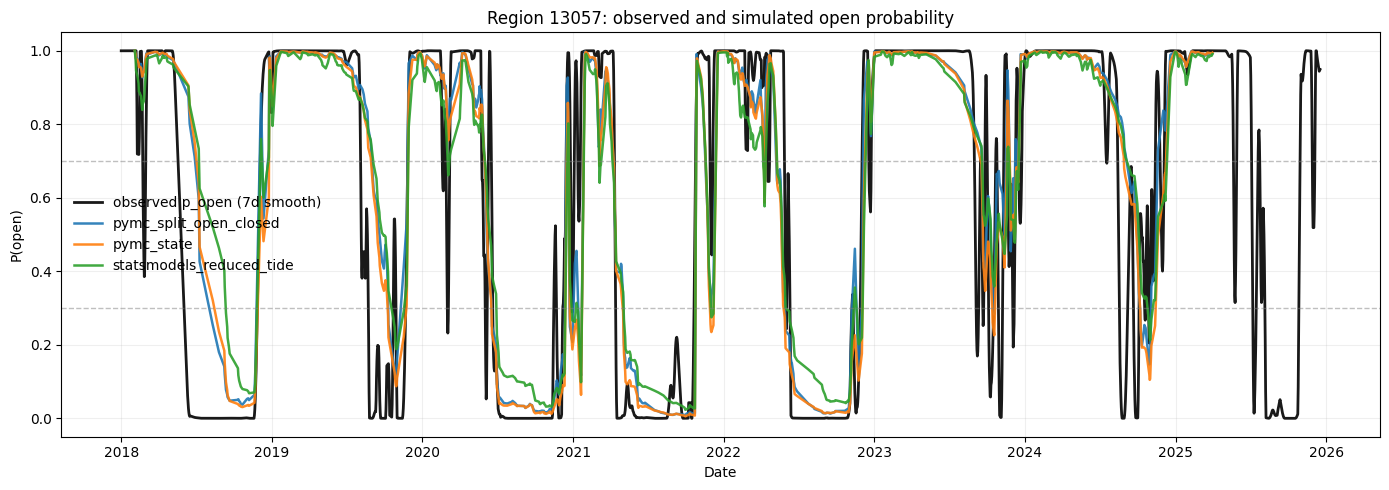

In [62]:
_ = plot_region_timeseries(
    sim_all=sim_all,
    model_df=model_df,
    region=13057,
    models=[
        "statsmodels_reduced_tide",
        "pymc_state",
        "pymc_split_open_closed",
    ],
)


In [63]:
def plot_region_model_with_inputs(
    sim_all,
    record_df,
    region,
    model_name,
    start=None,
    end=None,
    smooth_days=7,
):
    sub_sim = sim_all[
        (sim_all["region"] == region)
        & (sim_all["model"] == model_name)
    ].copy()

    sub_rec = record_df[record_df["region"] == region].copy()

    if start is not None:
        start = pd.Timestamp(start)
        sub_sim = sub_sim[sub_sim["date"] >= start]
        sub_rec = sub_rec[sub_rec["date"] >= start]

    if end is not None:
        end = pd.Timestamp(end)
        sub_sim = sub_sim[sub_sim["date"] <= end]
        sub_rec = sub_rec[sub_rec["date"] <= end]

    sub_sim = sub_sim.sort_values("date")
    sub_rec = sub_rec.sort_values("date")

    obs = (
        sub_rec[["date", "p_open"]]
        .drop_duplicates()
        .set_index("date")
        .sort_index()
    )

    obs["p_open_smooth"] = (
        obs["p_open"]
        .rolling(f"{smooth_days}D", min_periods=1)
        .mean()
    )

    labels = sub_rec[sub_rec["is_obs"]].copy()
    labels["state"] = np.select(
        [
            labels["p_open"] >= 0.7,
            labels["p_open"] <= 0.3,
        ],
        [
            "open",
            "closed",
        ],
        default="uncertain",
    )

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1, 1, 0.8]},
    )

    ax = axes[0]

    ax.plot(
        obs.index,
        obs["p_open_smooth"],
        label=f"observed ({smooth_days}d smooth)",
        color="black",
        linewidth=2,
    )

    ax.plot(
        sub_sim["date"],
        sub_sim["p_open_sim"],
        label=model_name,
        linewidth=1.6,
    )

    open_idx = labels["state"] == "open"
    closed_idx = labels["state"] == "closed"
    uncertain_idx = labels["state"] == "uncertain"

    ax.scatter(
        labels.loc[open_idx, "date"],
        [1.02] * open_idx.sum(),
        color="tab:blue",
        s=10,
        label="open obs",
        zorder=5,
    )
    ax.scatter(
        labels.loc[closed_idx, "date"],
        [-0.02] * closed_idx.sum(),
        color="tab:orange",
        s=10,
        label="closed obs",
        zorder=5,
    )
    ax.scatter(
        labels.loc[uncertain_idx, "date"],
        [0.5] * uncertain_idx.sum(),
        color="tab:gray",
        s=8,
        label="uncertain obs",
        alpha=0.5,
        zorder=5,
    )

    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, alpha=0.4)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=1, alpha=0.4)

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("p_open")
    ax.set_title(f"Region {region} | Model: {model_name}")
    ax.legend(loc="lower left", ncols=2)

    axes[1].plot(
        sub_rec["date"],
        sub_rec["flow_window"],
        label="flow_window",
        color="tab:blue",
        linewidth=1.4,
    )
    axes[1].plot(
        sub_rec["date"],
        sub_rec["flow_daily"],
        label="flow_daily",
        color="tab:cyan",
        linewidth=1.2,
        alpha=0.85,
    )

    axes[2].plot(
        sub_rec["date"],
        sub_rec["wave_window"],
        label="wave_window",
        color="tab:orange",
        linewidth=1.4,
    )
    axes[2].plot(
        sub_rec["date"],
        sub_rec["wave_daily"],
        label="wave_daily",
        color="tab:red",
        linewidth=1.2,
        alpha=0.85,
    )

    axes[3].plot(
        sub_rec["date"],
        sub_rec["tide_daily"],
        label="tide_daily",
        color="tab:green",
        linewidth=1.4,
    )

    axes[1].set_ylabel("flow")
    axes[2].set_ylabel("wave")
    axes[3].set_ylabel("tide")
    axes[3].set_xlabel("date")

    for ax in axes[1:]:
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="lower left")

    for ax in axes:
        ax.grid(alpha=0.2)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [64]:
sim_all.model.unique().tolist()

['statsmodels_reduced_tide', 'pymc_state', 'pymc_split_open_closed']

['statsmodels_reduced_tide', 'pymc_state', 'pymc_split_open_closed']


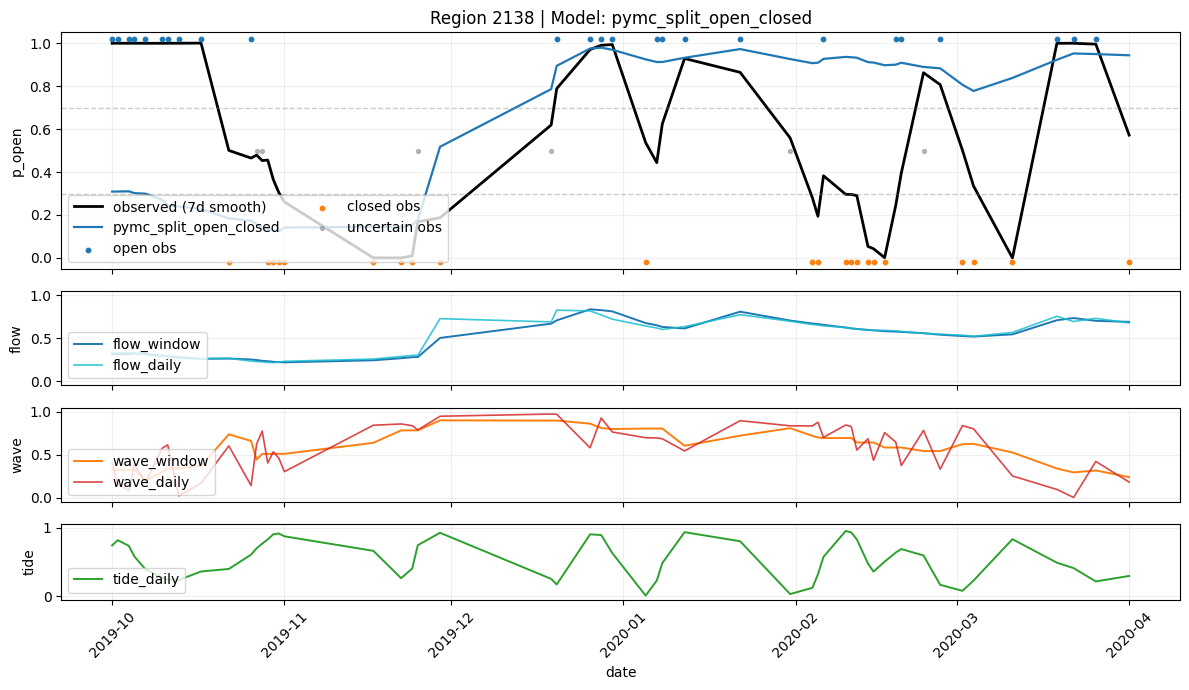

In [125]:
print(sim_all["model"].unique().tolist())

plot_region_model_with_inputs(
    sim_all=sim_all,
    record_df=record_df,
    region=2138,
    model_name="pymc_split_open_closed",
    start="2019-10-01",
    end="2020-04-01",`
    smooth_days=7,
)


In [143]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
)


# -------------------------
# 1. Add full-series transition predictions
# -------------------------

def add_full_series_transition_predictions(
    model_df,
    trace_closed,
    region_levels_closed_only,
    trace_open,
    region_levels_open_only,
):
    out = model_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    out["p_if_closed"] = predict_pymc_closed_model(
        trace_closed=trace_closed,
        df=out,
        region_levels_closed=region_levels_closed_only,
    )

    out["p_if_open"] = predict_pymc_open_model(
        trace_open=trace_open,
        df=out,
        region_levels_open=region_levels_open_only,
    )

    return out


# -------------------------
# 2. Simulate between consecutive real observations
# -------------------------

def build_observation_interval_eval_from_predictions(
    pred_df,
    min_open=0.7,
    min_closed=0.3,
):
    rows = []

    df = pred_df.sort_values(["region", "date"]).copy()

    for region, sub in df.groupby("region", sort=False):
        sub = sub.sort_values("date").reset_index(drop=True)

        obs_idx = sub.index[sub["is_obs"]].to_numpy()

        for start_idx, end_idx in zip(obs_idx[:-1], obs_idx[1:]):
            path = sub.loc[start_idx:end_idx].copy().reset_index(drop=True)

            if len(path) < 2:
                continue

            if path[["p_if_closed", "p_if_open"]].isna().any().any():
                continue

            start_p = float(path["p_open"].iloc[0])
            end_p = float(path["p_open"].iloc[-1])

            start_state = (
                "open" if start_p >= min_open
                else "closed" if start_p <= min_closed
                else "uncertain"
            )
            end_state = (
                "open" if end_p >= min_open
                else "closed" if end_p <= min_closed
                else "uncertain"
            )

            p_if_closed = path["p_if_closed"].to_numpy(dtype=float)
            p_if_open = path["p_if_open"].to_numpy(dtype=float)

            p_sim = np.empty(len(path), dtype=float)
            p_sim[0] = start_p

            for i in range(1, len(path)):
                p_sim[i] = (
                    (1 - p_sim[i - 1]) * p_if_closed[i]
                    + p_sim[i - 1] * p_if_open[i]
                )

            rows.append(
                {
                    "region": region,
                    "start_date": path["date"].iloc[0],
                    "end_date": path["date"].iloc[-1],
                    "n_days": (path["date"].iloc[-1] - path["date"].iloc[0]).days,
                    "start_p_open": start_p,
                    "end_p_open": end_p,
                    "start_state": start_state,
                    "end_state": end_state,
                    "y_end_open": int(end_state == "open"),
                    "y_end_closed": int(end_state == "closed"),
                    "p_end_sim": float(p_sim[-1]),
                    "p_if_closed_end": float(p_if_closed[-1]),
                    "p_if_open_end": float(p_if_open[-1]),
                }
            )

    return pd.DataFrame(rows)


# -------------------------
# 3. Metrics
# -------------------------

def interval_skill_metrics(df, pred_col, y_col="y_end_open"):
    d = df.dropna(subset=[pred_col, y_col]).copy()

    # Only score confident open/closed endpoints.
    d = d[d["end_state"].isin(["open", "closed"])].copy()

    y = d[y_col].to_numpy()
    p = d[pred_col].clip(1e-6, 1 - 1e-6).to_numpy()

    out = {
        "n": len(d),
        "n_open": int(y.sum()),
        "open_rate": float(y.mean()),
        "log_loss": log_loss(y, p),
        "brier": brier_score_loss(y, p),
        "mean_pred": float(p.mean()),
        "mean_pred_open": float(p[y == 1].mean()) if y.sum() else np.nan,
        "mean_pred_closed": float(p[y == 0].mean()) if (y == 0).sum() else np.nan,
    }

    if len(np.unique(y)) == 2:
        out["roc_auc"] = roc_auc_score(y, p)
        out["avg_precision"] = average_precision_score(y, p)
    else:
        out["roc_auc"] = np.nan
        out["avg_precision"] = np.nan

    return pd.DataFrame([out])


def compare_interval_models(interval_eval, subset_name="all"):
    d = interval_eval.copy()

    # Only confident endpoints are scored.
    d = d[d["end_state"].isin(["open", "closed"])].copy()

    base_rate = d["y_end_open"].mean()
    d["p_baseline"] = base_rate

    metrics = pd.concat(
        [
            interval_skill_metrics(d, "p_baseline").assign(
                model="baseline",
                subset=subset_name,
            ),
            interval_skill_metrics(d, "p_end_sim").assign(
                model="pymc_split",
                subset=subset_name,
            ),
            interval_skill_metrics(d, "p_if_closed_end").assign(
                model="p_if_closed_end",
                subset=subset_name,
            ),
            interval_skill_metrics(d, "p_if_open_end").assign(
                model="p_if_open_end",
                subset=subset_name,
            ),
        ],
        ignore_index=True,
    )

    return metrics[
        [
            "subset",
            "model",
            "n",
            "n_open",
            "open_rate",
            "log_loss",
            "brier",
            "mean_pred",
            "mean_pred_open",
            "mean_pred_closed",
            "roc_auc",
            "avg_precision",
        ]
    ].sort_values(["subset", "log_loss"])


# -------------------------
# 4. Run evaluation
# -------------------------

pred_daily = add_full_series_transition_predictions(
    model_df=model_df,
    trace_closed=trace_closed,
    region_levels_closed_only=region_levels_closed_only,
    trace_open=trace_open,
    region_levels_open_only=region_levels_open_only,
)

interval_eval = build_observation_interval_eval_from_predictions(
    pred_daily,
    min_open=0.7,
    min_closed=0.3,
)

interval_metrics_all = compare_interval_models(
    interval_eval,
    subset_name="all_start_states",
)

interval_metrics_start_closed = compare_interval_models(
    interval_eval[interval_eval["start_state"] == "closed"].copy(),
    subset_name="start_closed",
)

interval_metrics_start_open = compare_interval_models(
    interval_eval[interval_eval["start_state"] == "open"].copy(),
    subset_name="start_open",
)

interval_metrics = pd.concat(
    [
        interval_metrics_all,
        interval_metrics_start_closed,
        interval_metrics_start_open,
    ],
    ignore_index=True,
)

interval_metrics


,subset,model,n,n_open,open_rate,log_loss,brier,mean_pred,mean_pred_open,mean_pred_closed,roc_auc,avg_precision
0,all_start_states,pymc_split,16940,9287,0.548229,0.142383,0.039930,0.542948,0.912459,0.094542,0.987632,0.989827
1,all_start_states,p_if_open_end,16940,9287,0.548229,0.537363,0.173033,0.754056,0.943929,0.523643,0.933584,0.942258
2,all_start_states,baseline,16940,9287,0.548229,0.688488,0.247674,0.548229,0.548229,0.548229,0.500000,0.548229
3,all_start_states,p_if_closed_end,16940,9287,0.548229,0.740863,0.198242,0.331036,0.554549,0.059802,0.886787,0.919995
4,start_closed,p_if_closed_end,7579,350,0.046180,0.121249,0.032431,0.065106,0.423949,0.047732,0.909969,0.514852
5,start_closed,pymc_split,7579,350,0.046180,0.132288,0.036771,0.089653,0.543709,0.067669,0.923057,0.555935
6,start_closed,baseline,7579,350,0.046180,0.187111,0.044048,0.046180,0.046180,0.046180,0.500000,0.046180
7,start_closed,p_if_open_end,7579,350,0.046180,1.033577,0.340851,0.525170,0.775634,0.513044,0.761750,0.173414
8,start_open,p_if_open_end,9172,8843,0.964130,0.119455,0.031873,0.943319,0.951771,0.716149,0.886543,0.994844
9,start_open,pymc_split,9172,8843,0.964130,0.140185,0.038836,0.917643,0.929806,0.590714,0.902454,0.995754


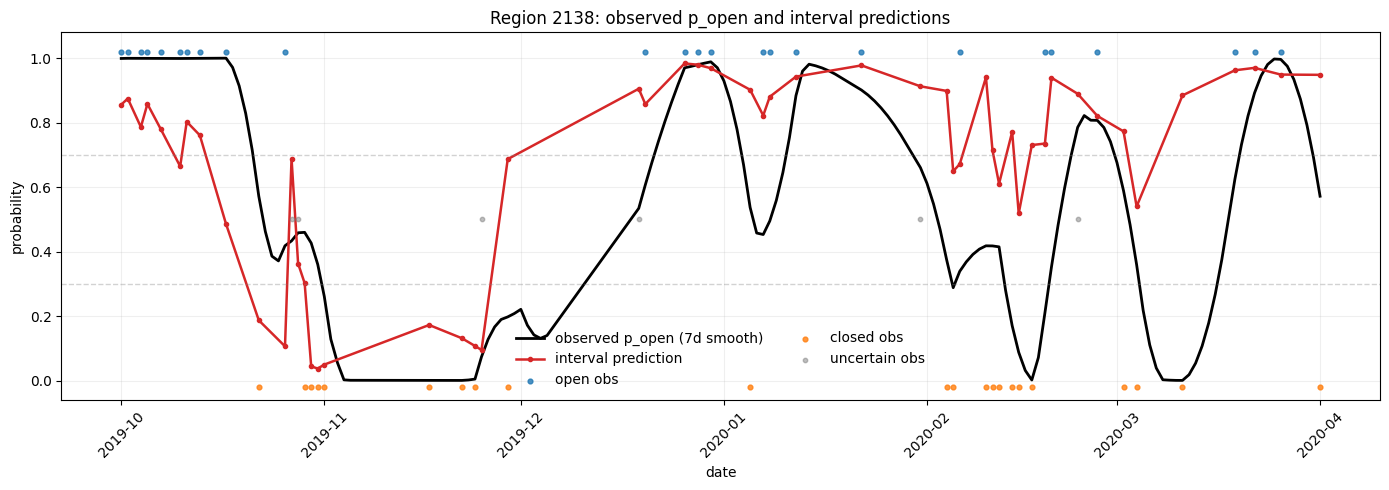

(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'Region 2138: observed p_open and interval predictions'}, xlabel='date', ylabel='probability'>)

In [144]:
def build_interval_prediction_plot_df(
    model_df,
    interval_eval,
    pred_col="p_end_sim",
):
    plot_df = model_df.copy().sort_values(["region", "date"]).reset_index(drop=True)

    interval_pred = (
        interval_eval[
            [
                "region",
                "end_date",
                "p_end_sim",
                "p_if_closed_end",
                "p_if_open_end",
                "start_state",
                "end_state",
                "start_date",
                "n_days",
            ]
        ]
        .copy()
        .rename(columns={"end_date": "date"})
    )

    plot_df = plot_df.merge(
        interval_pred,
        on=["region", "date"],
        how="left",
    )

    plot_df["state_plot"] = np.select(
        [
            plot_df["p_open"] >= 0.7,
            plot_df["p_open"] <= 0.3,
        ],
        [
            "open",
            "closed",
        ],
        default="uncertain",
    )

    return plot_df

def plot_interval_predictions(
    plot_df,
    region,
    pred_col="p_end_sim",
    start=None,
    end=None,
    smooth_days=7,
    figsize=(14, 5),
):
    sub = plot_df[plot_df["region"] == region].copy()

    if start is not None:
        start = pd.Timestamp(start)
        sub = sub[sub["date"] >= start]

    if end is not None:
        end = pd.Timestamp(end)
        sub = sub[sub["date"] <= end]

    sub = sub.sort_values("date")

    obs = (
        sub[["date", "p_open"]]
        .drop_duplicates()
        .set_index("date")
        .sort_index()
    )
    obs["p_open_smooth"] = (
        obs["p_open"]
        .rolling(f"{smooth_days}D", min_periods=1)
        .mean()
    )

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        obs.index,
        obs["p_open_smooth"],
        color="black",
        linewidth=2,
        label=f"observed p_open ({smooth_days}d smooth)",
    )

    pred_pts = sub[sub[pred_col].notna()].copy()

    ax.plot(
        pred_pts["date"],
        pred_pts[pred_col],
        color="tab:red",
        linewidth=1.8,
        marker="o",
        markersize=3,
        label="interval prediction",
    )

    obs_pts = sub[sub["is_obs"]].copy()

    open_idx = obs_pts["state_plot"] == "open"
    closed_idx = obs_pts["state_plot"] == "closed"
    uncertain_idx = obs_pts["state_plot"] == "uncertain"

    ax.scatter(
        obs_pts.loc[open_idx, "date"],
        [1.02] * open_idx.sum(),
        color="tab:blue",
        s=12,
        alpha=0.8,
        label="open obs",
        zorder=5,
    )

    ax.scatter(
        obs_pts.loc[closed_idx, "date"],
        [-0.02] * closed_idx.sum(),
        color="tab:orange",
        s=12,
        alpha=0.8,
        label="closed obs",
        zorder=5,
    )

    ax.scatter(
        obs_pts.loc[uncertain_idx, "date"],
        [0.5] * uncertain_idx.sum(),
        color="tab:gray",
        s=10,
        alpha=0.5,
        label="uncertain obs",
        zorder=5,
    )

    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, alpha=0.35)
    ax.axhline(0.3, color="gray", linestyle="--", linewidth=1, alpha=0.35)

    ax.set_ylim(-0.06, 1.08)
    ax.set_ylabel("probability")
    ax.set_xlabel("date")
    ax.set_title(f"Region {region}: observed p_open and interval predictions")
    ax.grid(alpha=0.2)
    ax.legend(loc="best", frameon=False, ncols=2)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return fig, ax

interval_plot_df = build_interval_prediction_plot_df(
    model_df=model_df,
    interval_eval=interval_eval,
    pred_col="p_end_sim",
)

plot_interval_predictions(
    interval_plot_df,
    region=2138,
    pred_col="p_end_sim",
    start="2019-10-01",
    end="2020-04-01",
    smooth_days=7,
)


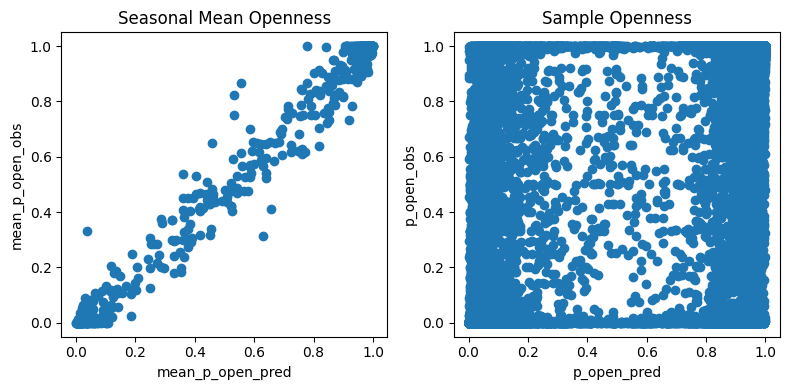

Daily R^2: 0.777
Seasonal R^2: 0.979


In [226]:
seasonal_summary = record_df.groupby(["region", "year", "season"], as_index=False).agg(
    mean_p_open_obs=("p_open", "mean"),
    mean_p_open_pred=("p_open_hat", "mean"),
    var_p_open=("p_open", "var"),
    mean_flow=("flow_rank", "mean"),
    mean_wave=("wave_rank", "mean"),
)
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 4))
axes[0].scatter(
    x=seasonal_summary["mean_p_open_pred"],
    y=seasonal_summary["mean_p_open_obs"],
)
axes[0].set_title("Seasonal Mean Openness")
axes[0].set_xlabel("mean_p_open_pred")
axes[0].set_ylabel("mean_p_open_obs")
axes[1].scatter(
    x=record_df["p_open_hat"],
    y=record_df["p_open"],
)
axes[1].set_title("Sample Openness")
axes[1].set_xlabel("p_open_pred")
axes[1].set_ylabel("p_open_obs")
fig.tight_layout()
plt.show()

print("Daily R^2:", round(r2_score(record_df["p_open"], record_df["p_open_hat"]), 3))
print(
    "Seasonal R^2:",
    round(r2_score(seasonal_summary["mean_p_open_obs"], seasonal_summary["mean_p_open_pred"]), 3),
)

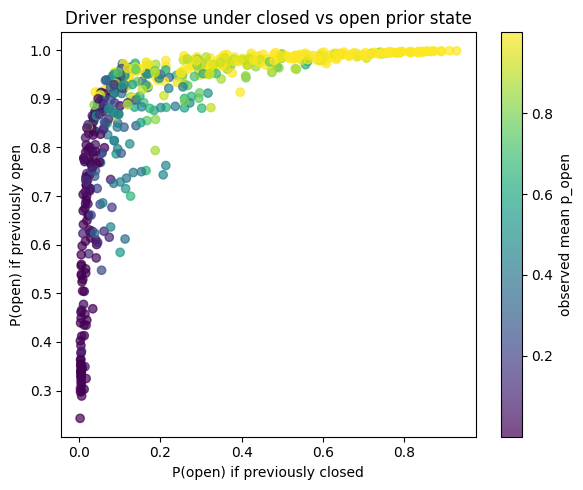

In [227]:
cf = record_df.copy()

cf_closed = cf.copy()
cf_closed["state_prev"] = "closed"
cf["p_open_if_closed"] = m.predict(cf_closed)

cf_open = cf.copy()
cf_open["state_prev"] = "open"
cf["p_open_if_open"] = m.predict(cf_open)

cf["persistence_gap"] = cf["p_open_if_open"] - cf["p_open_if_closed"]

seasonal_cf = cf.groupby(["region", "year", "season"], as_index=False).agg(
    obs_open=("p_open", "mean"),
    driver_open_from_closed=("p_open_if_closed", "mean"),
    driver_open_from_open=("p_open_if_open", "mean"),
    p_open_mean=("p_open", "mean"),
    persistence_gap=("persistence_gap", "mean"),
    flow=("flow_rank", "mean"),
    wave=("wave_rank", "mean"),
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    seasonal_cf["driver_open_from_closed"],
    seasonal_cf["driver_open_from_open"],
    c=seasonal_cf["obs_open"],
    alpha=0.7,
)

ax.set_xlabel("P(open) if previously closed")
ax.set_ylabel("P(open) if previously open")
ax.set_title("Driver response under closed vs open prior state")

plt.colorbar(ax.collections[0], label="observed mean p_open")
plt.tight_layout()
plt.show()

# Persistance Gap by Season/Water Year
> When forcing is strong (winter), the system is driver-controlled. When forcing is weak (summer), the system is state-controlled.

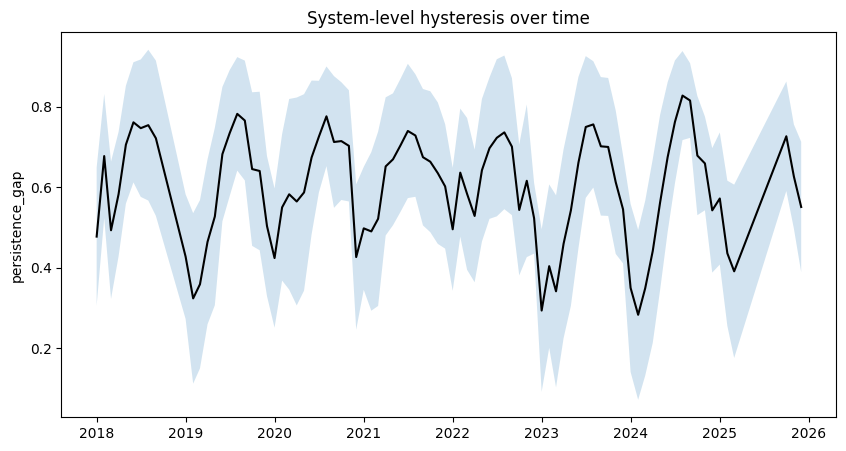

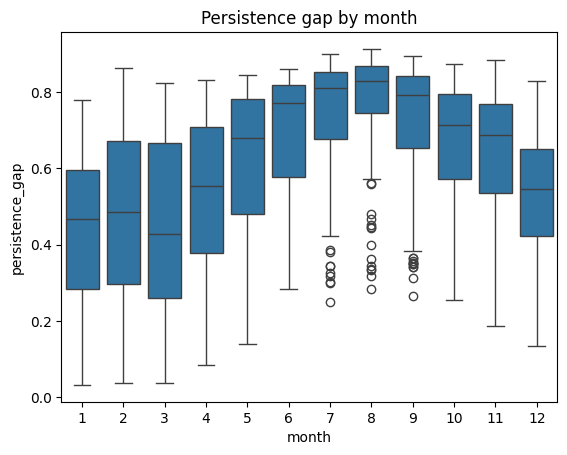

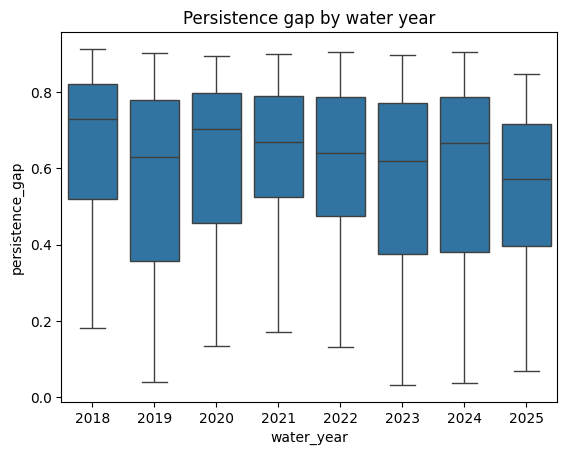

In [228]:
monthly_gap = cf.groupby(["region", "water_year", "month"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
    open_from_closed=("p_open_if_closed", "mean"),
    open_from_open=("p_open_if_open", "mean"),
)
monthly_gap_mean = monthly_gap.groupby(["water_year", "month"], as_index=False).agg(
    persistence_gap=("persistence_gap", "mean"),
    gap_std=("persistence_gap", "std"),
)
monthly_gap_mean["time"] = pd.to_datetime(
    dict(year=monthly_gap_mean.water_year, month=monthly_gap_mean.month, day=1)
)

plt.figure(figsize=(10, 5))

plt.plot(monthly_gap_mean["time"], monthly_gap_mean["persistence_gap"], color="black")

plt.fill_between(
    monthly_gap_mean["time"],
    monthly_gap_mean["persistence_gap"] - monthly_gap_mean["gap_std"],
    monthly_gap_mean["persistence_gap"] + monthly_gap_mean["gap_std"],
    alpha=0.2,
)

plt.ylabel("persistence_gap")
plt.title("System-level hysteresis over time")
plt.show()

plt.figure()
sns.boxplot(data=monthly_gap, x="month", y="persistence_gap")

plt.title("Persistence gap by month")
plt.show()

plt.figure()
sns.boxplot(data=monthly_gap, x="water_year", y="persistence_gap")

plt.title("Persistence gap by water year")
plt.show()

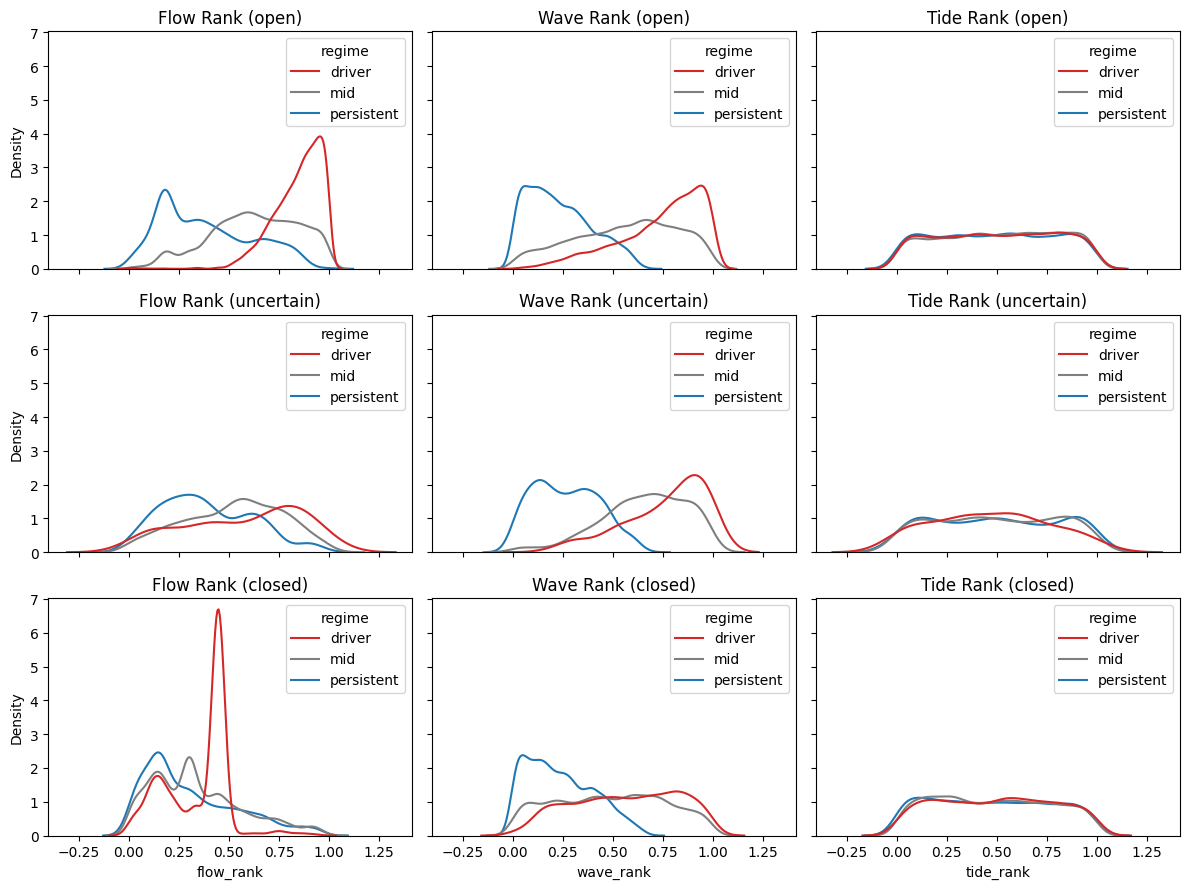

In [229]:
df = cf.copy()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 9), sharex=True, sharey=True)

# thresholds
low_thresh = df["persistence_gap"].quantile(0.25)
high_thresh = df["persistence_gap"].quantile(0.75)

df["regime"] = "mid"
df.loc[df["persistence_gap"] <= low_thresh, "regime"] = "driver"
df.loc[df["persistence_gap"] >= high_thresh, "regime"] = "persistent"

# consistent colors
palette = {
    "driver": "tab:red",
    "mid": "tab:gray",
    "persistent": "tab:blue",
}
hue_order = ["driver", "mid", "persistent"]

states = ["open", "uncertain", "closed"]
vars_ = ["flow_rank", "wave_rank", "tide_rank"]

for i, state in enumerate(states):
    sub = df[df["state"] == state]
    for j, var in enumerate(vars_):
        sns.kdeplot(
            data=sub,
            x=var,
            hue="regime",
            hue_order=hue_order,
            palette=palette,
            common_norm=False,
            ax=axes[i, j],
        )
        axes[i, j].set_title(f"{var.replace('_', ' ').title()} ({state})")

fig.tight_layout()
plt.show()

In [230]:
def simulate_expected_path(
    df_region: pd.DataFrame,
    model,
    initial_p_open: float | None = None,
) -> pd.DataFrame:
    sub = df_region.sort_values("date").copy().reset_index(drop=True)

    if initial_p_open is None:
        initial_p_open = float(sub["p_open"].iloc[0])

    # Predict both transition probabilities in one batch each
    rows_closed = sub.copy()
    rows_open = sub.copy()

    rows_closed["state_prev"] = "closed"
    rows_open["state_prev"] = "open"

    p_if_closed = model.predict(rows_closed).to_numpy(dtype=float)
    p_if_open = model.predict(rows_open).to_numpy(dtype=float)

    p_sim = np.empty(len(sub), dtype=float)
    p_sim[0] = initial_p_open

    for i in range(1, len(sub)):
        p_sim[i] = (
            (1 - p_sim[i - 1]) * p_if_closed[i]
            + p_sim[i - 1] * p_if_open[i]
        )

    out = sub.copy()
    out["p_if_closed"] = p_if_closed
    out["p_if_open"] = p_if_open
    out["p_open_sim"] = p_sim

    return out


sim_frames = []

for region, sub in tqdm.tqdm(record_df.groupby("region"), total=len(model_df.region.unique())):
    sim_frames.append(
        simulate_expected_path(
            df_region=sub,
            model=m,
            initial_p_open=float(sub.sort_values("date")["p_open"].iloc[0]),
        )
    )

sim_df = pd.concat(sim_frames, ignore_index=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 93.75it/s]


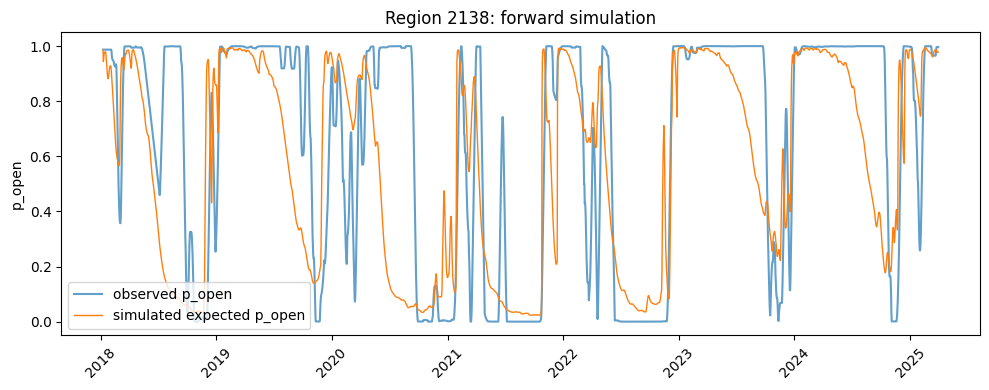

In [233]:
r = 2138

sub = sim_df[sim_df["region"] == r].sort_values("date").reset_index()
sub["p_open_smooth"] = (
    sub.set_index("date")["p_open"].rolling("14D").mean().reset_index(level=0, drop=True)
)
# sub = sub[sub.date.between("2023-01-01", "2024-01-01")]

plt.figure(figsize=(10, 4))
plt.plot(sub["date"], sub["p_open_smooth"], label="observed p_open", alpha=0.7)
plt.plot(sub["date"], sub["p_open_sim"], label="simulated expected p_open", linewidth=1)
# plt.plot(sub["date"], sub["tide_rank"], label="simulated expected p_open", linewidth=1, color="red")
plt.legend(loc="lower left")
plt.title(f"Region {r}: forward simulation")
plt.ylabel("p_open")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig("/Users/kyledorman/Desktop/2138.png")
plt.show()

In [73]:
def simulate_mc_paths_fast(
    df_region: pd.DataFrame,
    model,
    n_sims: int = 1000,
    initial_state: str | None = None,
    random_seed: int = 42,
    rolling_window: int = 7,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_seed)

    sub = df_region.sort_values("date").copy().reset_index(drop=True)

    if initial_state is None:
        initial_state = "open" if sub["p_open"].iloc[0] >= 0.5 else "closed"

    paths = np.zeros((n_sims, len(sub)), dtype=np.int8)
    paths[:, 0] = 1 if initial_state == "open" else 0

    closed_rows = sub.copy()
    closed_rows["state_prev"] = "closed"
    p_if_closed = model.predict(closed_rows).to_numpy()

    open_rows = sub.copy()
    open_rows["state_prev"] = "open"
    p_if_open = model.predict(open_rows).to_numpy()

    for i in range(1, len(sub)):
        prev_open = paths[:, i - 1].astype(bool)
        p_open = np.where(prev_open, p_if_open[i], p_if_closed[i])
        paths[:, i] = rng.random(n_sims) < p_open

    # Raw daily path summaries
    out = sub.copy()
    out["mc_mean"] = paths.mean(axis=0)
    out["mc_q05"] = np.quantile(paths, 0.05, axis=0)
    out["mc_q25"] = np.quantile(paths, 0.25, axis=0)
    out["mc_q75"] = np.quantile(paths, 0.75, axis=0)
    out["mc_q95"] = np.quantile(paths, 0.95, axis=0)

    # Rolling path summaries: smooth each simulated path first, then take quantiles.
    paths_roll = (
        pd.DataFrame(paths.T).rolling(window=rolling_window, min_periods=1).mean().to_numpy().T
    )

    out[f"mc_roll{rolling_window}_mean"] = paths_roll.mean(axis=0)
    out[f"mc_roll{rolling_window}_q05"] = np.quantile(paths_roll, 0.05, axis=0)
    out[f"mc_roll{rolling_window}_q25"] = np.quantile(paths_roll, 0.25, axis=0)
    out[f"mc_roll{rolling_window}_q75"] = np.quantile(paths_roll, 0.75, axis=0)
    out[f"mc_roll{rolling_window}_q95"] = np.quantile(paths_roll, 0.95, axis=0)

    # Rolling observed p_open for comparable visualization.
    out[f"p_open_roll{rolling_window}"] = (
        out["p_open"].rolling(window=rolling_window, min_periods=1).mean()
    )

    return out

In [ ]:
mc_frames = []

for region, sub in tqdm.tqdm(model_df.groupby("region"), total=model_df["region"].nunique()):
    mc_frames.append(
        simulate_mc_paths_fast(
            df_region=sub,
            model=m,
            n_sims=1000,
            initial_state=None,
            random_seed=int(region),
            rolling_window=14,
        )
    )

mc_df = pd.concat(mc_frames, ignore_index=True)

mc_df.head()

In [ ]:
r = 84
w = 14

sub = mc_df[mc_df["region"] == r].sort_values("date").copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    sub["date"],
    sub[f"p_open_roll{w}"],
    label=f"observed p_open ({w}d mean)",
    alpha=0.6,
    color="blue",
)
ax.plot(sub["date"], sub[f"mc_roll{w}_mean"], label=f"MC mean ({w}d mean)", color="orange")

# ax.fill_between(
#     sub["date"],
#     sub[f"mc_roll{w}_q05"],
#     sub[f"mc_roll{w}_q95"],
#     alpha=0.15,
#     label="5–95%",
#     color="red",
# )

ax.fill_between(
    sub["date"],
    sub[f"mc_roll{w}_q25"],
    sub[f"mc_roll{w}_q75"],
    alpha=0.25,
    label="25–75%",
    color="orange",
)

ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower left")
ax.set_title(f"Region {r}")
plt.tight_layout()
plt.show()

In [ ]:
w = 14

mc_df["inside_50"] = (mc_df[f"p_open_roll{w}"] >= mc_df[f"mc_roll{w}_q25"]) & (
    mc_df[f"p_open_roll{w}"] <= mc_df[f"mc_roll{w}_q75"]
)

mc_df["inside_90"] = (mc_df[f"p_open_roll{w}"] >= mc_df[f"mc_roll{w}_q05"]) & (
    mc_df[f"p_open_roll{w}"] <= mc_df[f"mc_roll{w}_q95"]
)

mc_df["error"] = mc_df[f"p_open_roll{w}"] - mc_df[f"mc_roll{w}_mean"]
mc_df["abs_error"] = mc_df["error"].abs()
mc_df["sq_error"] = mc_df["error"] ** 2

print("50% coverage:", mc_df["inside_50"].mean())
print("90% coverage:", mc_df["inside_90"].mean())

cov_region = (
    mc_df.groupby("region", as_index=False)
    .agg(
        cov_50=("inside_50", "mean"),
        cov_90=("inside_90", "mean"),
        n=("inside_50", "size"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda s: np.sqrt(s.mean())),
        bias=("error", "mean"),
    )
    .sort_values("cov_50")
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(cov_region["cov_50"], cov_region["cov_90"])

for _, row in cov_region.iterrows():
    ax.text(row["cov_50"], row["cov_90"], str(row["region"]), fontsize=8)

# reference lines
ax.axvline(0.5, linestyle="--", color="gray")
ax.axhline(0.9, linestyle="--", color="gray")

ax.set_xlabel("50% coverage")
ax.set_ylabel("90% coverage")
ax.set_title("Coverage by estuary")

plt.tight_layout()
plt.show()

cov_region.sort_values("cov_50").plot.bar(x="region", y=["cov_50", "cov_90"], figsize=(8, 4))
plt.axhline(0.5, linestyle="--", color="gray")
plt.axhline(0.9, linestyle="--", color="gray")
plt.ylabel("coverage")
plt.title("Coverage per region")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(cov_region["region"].astype(str), cov_region["mae"])

ax.set_xlabel("region")
ax.set_ylabel("MAE")
ax.set_title("Mean absolute error by region")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    cov_region["cov_50"],
    cov_region["cov_90"],
    c=cov_region["mae"],  # color = error
    cmap="viridis",
    s=80,
)

# labels
for _, row in cov_region.iterrows():
    ax.text(row["cov_50"], row["cov_90"], str(row["region"]), fontsize=8)

# reference lines (ideal calibration)
ax.axvline(0.5, linestyle="--", color="gray")
ax.axhline(0.9, linestyle="--", color="gray")

ax.set_xlabel("50% coverage")
ax.set_ylabel("90% coverage")
ax.set_title("Calibration vs Error (color = MAE)")

plt.colorbar(sc, label="MAE")
plt.tight_layout()
plt.show()

In [ ]:
sim_df["error"] = sim_df["p_open"] - sim_df["p_open_sim"]
sim_df["abs_error"] = sim_df["error"].abs()
sim_df["sq_error"] = sim_df["error"] ** 2

region_err = (
    sim_df.groupby("region", as_index=False)
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda s: np.sqrt(s.mean())),
        bias=("error", "mean"),
        n=("error", "size"),
    )
    .sort_values("mae", ascending=False)
)

plt.figure(figsize=(6, 4))
plt.bar(region_err["region"].astype(str), region_err["mae"])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Error by region")
plt.show()

year_err = sim_df.groupby("water_year", as_index=False).agg(
    mae=("abs_error", "mean"),
    rmse=("sq_error", lambda s: np.sqrt(s.mean())),
    bias=("error", "mean"),
)

plt.plot(year_err["water_year"], year_err["mae"], marker="o")
plt.ylabel("MAE")
plt.title("Error by water year")
plt.show()

sim_df["month"] = pd.to_datetime(sim_df["date"]).dt.month

month_err = sim_df.groupby("month", as_index=False).agg(
    mae=("abs_error", "mean"),
    rmse=("sq_error", lambda s: np.sqrt(s.mean())),
    bias=("error", "mean"),
)

plt.plot(month_err["month"], month_err["mae"], marker="o")
plt.xlabel("month")
plt.ylabel("MAE")
plt.title("Error by month")
plt.show()

rm = sim_df.groupby(["region", "month"], as_index=False).agg(mae=("abs_error", "mean"))

overall = sim_df["abs_error"].mean()
print("Overall MAE:", overall)

In [ ]:
sim_seasonal = sim_df.groupby(["region", "year", "wy_season"], as_index=False).agg(
    obs_open=("p_open", "mean"),
    sim_open=("p_open_sim", "mean"),
)

plt.figure(figsize=(5, 5))
plt.scatter(sim_seasonal["sim_open"], sim_seasonal["obs_open"], alpha=0.6)
plt.xlabel("forward simulated seasonal openness")
plt.ylabel("observed seasonal openness")
plt.title("Forward simulation vs observed seasonal openness")
plt.tight_layout()
plt.show()